## DP1 CDFS photometry diagnostics

This notebook validates the photometric behaviour of the LSST-VISTA Fusion Pipeline products in the CDFS/ECDFS region. The main catalogue contains forced photometry in the six LSST/ComCam optical bands and five VISTA/VIRCAM near-infrared bands, while the VIDEO public catalogue provides an external reference for the near-infrared measurements.

The photometric diagnostics use the forced circular-aperture measurements consistently across bands. Quality selection is applied independently in each band using the aperture-photometry measurement flag together with the relevant pixel-quality flags. This is important because a successful aperture measurement does not by itself guarantee that the underlying image pixels are suitable for scientific photometry.

The notebook examines DP1-VIDEO photometric residuals, magnitude distributions, colour-colour behaviour, stellar photometric consistency, aperture dependence, and bright-end residual trends.

### 1. Imports, paths, and catalogue loading

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import astropy.units as u
from astropy.table import Table
from astropy.coordinates import SkyCoord, match_coordinates_sky
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patheffects as pe

DATA_DIR = Path("../data")

DP1_PATH   = DATA_DIR / "full_reduced_cat_DP1_20260921.fits"
VIDEO_PATH = DATA_DIR / "VISTA-VIDEO-CDFS-DR5.fits"

OUTDIR = Path("data/plots_photometry")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Photometric selection
MAGERR_5SIG = 2.5 / np.log(10) / 5.0
MAGERR_3SIG = 2.5 / np.log(10) / 3.0

MATCH_RADIUS = 0.5 * u.arcsec
VIDEO_APER = 2

SAVE_FIGURES = True

dp1 = Table.read(DP1_PATH)
vid = Table.read(VIDEO_PATH)

print("DP1 rows :", len(dp1))
print("VIDEO rows:", len(vid))
print("DP1 columns:", len(dp1.colnames))
print("VIDEO columns:", len(vid.colnames))
print("Output directory:", OUTDIR)

DP1 rows : 1477389
VIDEO rows: 1138485
DP1 columns: 274
VIDEO columns: 389
Output directory: data/plots_photometry


### 2. Column definitions and per-band quality helpers

The most important part of this notebook is the function `dp1_band_usable`.

For each band, it requires:

- finite magnitude,
- finite magnitude error,
- positive magnitude error,
- magnitude error below the chosen limit,
- unflagged aperture-flux measurement,
- valid coverage **if a coverage column exists**.

In [2]:
DP1_PREFIX = {
    "u": "ComCam_u_f",
    "g": "ComCam_g_f",
    "r": "ComCam_r_f",
    "i": "ComCam_i_f",
    "z": "ComCam_z_f",
    "y": "ComCam_y_f",
    "Z": "VIRCAM_Z_f",
    "Y": "VIRCAM_Y_f",
    "J": "VIRCAM_J_f",
    "H": "VIRCAM_H_f",
    "K": "VIRCAM_K_f",
}

VIDEO_PREFIX = {
    "Z": "Z",
    "Y": "Y",
    "J": "J",
    "H": "H",
    "K": "KS",
}

APER = "base_CircularApertureFlux_6_0"


# Severe pixel-quality conditions that make the forced measurement
# unsuitable for the clean photometric samples used here.
BAD_PIXEL_FLAGS = [
    "offimage",
    "edgeCenterAll",
    "nodataCenterAll",
    "interpolatedCenterAll",
    "saturatedCenterAll",
    "crCenterAll",
    "badCenterAll",
    "clippedCenterAll",
    "rejectedCenterAll",
]


def has_col(tab, col):
    return col in tab.colnames


def arr(tab, col, dtype=float):
    if col not in tab.colnames:
        raise KeyError(f"Missing column: {col}")

    return np.asarray(
        np.ma.filled(tab[col], np.nan if dtype is float else True),
        dtype=dtype,
    )


def dp1_cols(band):
    prefix = DP1_PREFIX[band]

    return {
        "mag": f"{prefix}_{APER}_mag",
        "magErr": f"{prefix}_{APER}_magErr",
        "flux": f"{prefix}_{APER}_flux",
        "fluxErr": f"{prefix}_{APER}_fluxErr",
        "flag": f"{prefix}_{APER}_flag",
        "pixel_flags": {
            name: f"{prefix}_base_PixelFlags_flag_{name}"
            for name in BAD_PIXEL_FLAGS
        },
    }


def dp1_mag(tab, band):
    return arr(tab, dp1_cols(band)["mag"], float)


def dp1_err(tab, band):
    return arr(tab, dp1_cols(band)["magErr"], float)


def dp1_flux(tab, band):
    return arr(tab, dp1_cols(band)["flux"], float)


def dp1_flux_err(tab, band):
    return arr(tab, dp1_cols(band)["fluxErr"], float)


def dp1_flag(tab, band):
    return arr(
        tab,
        dp1_cols(band)["flag"],
        bool,
    )


def dp1_bad_pixel(tab, band):

    bad = np.zeros(len(tab), dtype=bool)

    for col in dp1_cols(band)["pixel_flags"].values():
        bad |= arr(tab, col, bool)

    return bad


def dp1_snr(tab, band):

    flux = dp1_flux(tab, band)
    flux_err = dp1_flux_err(tab, band)

    snr = np.full(len(tab), np.nan)

    good = (
        np.isfinite(flux)
        & np.isfinite(flux_err)
        & (flux_err > 0)
    )

    snr[good] = flux[good] / flux_err[good]

    return snr


def dp1_band_usable(tab, band, snr_min=5.0):

    mag = dp1_mag(tab, band)
    flux = dp1_flux(tab, band)
    flux_err = dp1_flux_err(tab, band)

    aperture_flag = dp1_flag(tab, band)
    bad_pixel = dp1_bad_pixel(tab, band)

    snr = dp1_snr(tab, band)

    return (
        np.isfinite(mag)
        & np.isfinite(flux)
        & np.isfinite(flux_err)
        & (flux_err > 0)
        & (~aperture_flag)
        & (~bad_pixel)
        & (snr >= snr_min)
    )


def dp1_colour(tab, band1, band2):
    return dp1_mag(tab, band1) - dp1_mag(tab, band2)


def nmad(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if x.size == 0:
        return np.nan

    med = np.nanmedian(x)

    return 1.4826 * np.nanmedian(
        np.abs(x - med)
    )


def qstats(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.array(
            [np.nan, np.nan, np.nan, np.nan, np.nan]
        )

    return np.nanpercentile(
        x,
        [5, 16, 50, 84, 95],
    )


def savefig(filename, dpi=300):

    if SAVE_FIGURES:
        plt.savefig(
            OUTDIR / filename,
            dpi=dpi,
            bbox_inches="tight",
        )

### 3. Band summary

This section summarizes the forced circular-aperture photometry in each band. It reports the number of finite measurements, measurements with an unset aperture flag, measurements that also pass the selected pixel-quality flags, and the final sample with forced-flux S/N >= 5.

In [3]:
def band_summary(tab, band):

    mag = dp1_mag(tab, band)
    flux = dp1_flux(tab, band)
    flux_err = dp1_flux_err(tab, band)

    aperture_flag = dp1_flag(tab, band)
    bad_pixel = dp1_bad_pixel(tab, band)
    snr = dp1_snr(tab, band)

    finite = (
        np.isfinite(mag)
        & np.isfinite(flux)
        & np.isfinite(flux_err)
        & (flux_err > 0)
    )

    aperture_ok = (
        finite
        & (~aperture_flag)
    )

    pixel_clean = (
        aperture_ok
        & (~bad_pixel)
    )

    usable = (
        pixel_clean
        & (snr >= 5.0)
    )

    print(f"Band {band}")

    print(
        f"  finite measurement   : "
        f"{finite.sum():8d} / {len(tab)}"
    )

    print(
        f"  aperture unflagged   : "
        f"{aperture_ok.sum():8d} / {len(tab)}"
    )

    print(
        f"  pixel clean          : "
        f"{pixel_clean.sum():8d} / {len(tab)}"
    )

    print(
        f"  usable S/N >= 5      : "
        f"{usable.sum():8d} / {len(tab)}"
    )

    if usable.sum() > 0:

        print(
            f"  mag range usable     : "
            f"{np.nanmin(mag[usable]):.3f} "
            f"to {np.nanmax(mag[usable]):.3f}"
        )

        print(
            f"  median S/N usable    : "
            f"{np.nanmedian(snr[usable]):.2f}"
        )

    print()


for band in [
    "Z", "Y", "J", "H", "K",
    "u", "g", "r", "i", "z", "y"
]:
    band_summary(dp1, band)

Band Z
  finite measurement   :   499194 / 1477389
  aperture unflagged   :   445398 / 1477389
  pixel clean          :   274397 / 1477389
  usable S/N >= 5      :   183272 / 1477389
  mag range usable     : 13.834 to 26.290
  median S/N usable    : 15.05

Band Y
  finite measurement   :  1212342 / 1477389
  aperture unflagged   :  1089321 / 1477389
  pixel clean          :   943626 / 1477389
  usable S/N >= 5      :   750109 / 1477389
  mag range usable     : 13.039 to 26.716
  median S/N usable    : 22.63

Band J
  finite measurement   :  1263446 / 1477389
  aperture unflagged   :  1136025 / 1477389
  pixel clean          :  1009013 / 1477389
  usable S/N >= 5      :   709232 / 1477389
  mag range usable     : 13.726 to 26.021
  median S/N usable    : 17.34

Band H
  finite measurement   :  1227741 / 1477389
  aperture unflagged   :  1104482 / 1477389
  pixel clean          :   925294 / 1477389
  usable S/N >= 5      :   614172 / 1477389
  mag range usable     : 13.543 to 25.469
  me

### 4. Coordinates and DP1--VIDEO cross-match

The DP1 and VIDEO catalogues are positionally matched once and the resulting associations are reused for the photometric diagnostics. DP1 coordinates are taken from the common catalogue source positions associated with the VIRCAM K-band reference catalogue. VIDEO is first restricted to the DP1 footprint, and matches are required to have separations below 0.35 arcsec.

In [4]:
DP1_RA  = "VIRCAM_K_m_coord_ra"   # radians in the DP1 table
DP1_DEC = "VIRCAM_K_m_coord_dec"  # radians in the DP1 table
VID_RA  = "RA2000"                # degrees
VID_DEC = "DEC2000"               # degrees

ra_dp1  = np.asarray(dp1[DP1_RA], dtype=float)
dec_dp1 = np.asarray(dp1[DP1_DEC], dtype=float)
m_dp1_coord = np.isfinite(ra_dp1) & np.isfinite(dec_dp1)

dp1c = dp1[m_dp1_coord]
c_dp1 = SkyCoord(
    ra=ra_dp1[m_dp1_coord] * u.rad,
    dec=dec_dp1[m_dp1_coord] * u.rad,
    frame="icrs",
)

ra_vid  = np.asarray(vid[VID_RA], dtype=float)
dec_vid = np.asarray(vid[VID_DEC], dtype=float)
m_vid_coord = np.isfinite(ra_vid) & np.isfinite(dec_vid)

vidc = vid[m_vid_coord]
c_vid = SkyCoord(
    ra=ra_vid[m_vid_coord] * u.deg,
    dec=dec_vid[m_vid_coord] * u.deg,
    frame="icrs",
)

print("Finite coordinates:")
print("  DP1  :", len(dp1c), "/", len(dp1))
print("  VIDEO:", len(vidc), "/", len(vid))

# Restrict VIDEO to the DP1 footprint for faster matching.
ra_dp1_deg = np.degrees(ra_dp1[m_dp1_coord])
dec_dp1_deg = np.degrees(dec_dp1[m_dp1_coord])

ra_min, ra_max = np.nanpercentile(ra_dp1_deg, [0.5, 99.5])
dec_min, dec_max = np.nanpercentile(dec_dp1_deg, [0.5, 99.5])

pad = 0.02
ra_min -= pad
ra_max += pad
dec_min -= pad
dec_max += pad

in_box = (
    (ra_vid[m_vid_coord] >= ra_min)
    & (ra_vid[m_vid_coord] <= ra_max)
    & (dec_vid[m_vid_coord] >= dec_min)
    & (dec_vid[m_vid_coord] <= dec_max)
)

vid_box = vidc[in_box]
c_vid_box = c_vid[in_box]

print("VIDEO rows in DP1 box:", len(vid_box))

idx, sep, _ = match_coordinates_sky(c_dp1, c_vid_box)
matched = sep < MATCH_RADIUS

print(f"Matches within {MATCH_RADIUS.to(u.arcsec).value:.2f} arcsec:", int(matched.sum()))

Finite coordinates:
  DP1  : 1477389 / 1477389
  VIDEO: 1138485 / 1138485
VIDEO rows in DP1 box: 549716
Matches within 0.50 arcsec: 810491


### 5. Baseline residual plots: sep < 0.50 arcsec

The residual comparison is performed independently in each VIRCAM band. The DP1 measurement must pass the forced-photometry quality selection defined above, including finite flux and uncertainty, positive uncertainty, an unset aperture-flux flag, no selected severe pixel-quality flag, and forced-flux S/N >= 5. The corresponding VIDEO aperture magnitude and uncertainty must be finite, the uncertainty must satisfy the adopted 5-sigma criterion, and the VIDEO quality flag must be zero.

The baseline positional association requires a DP1--VIDEO separation below 0.50 arcsec.

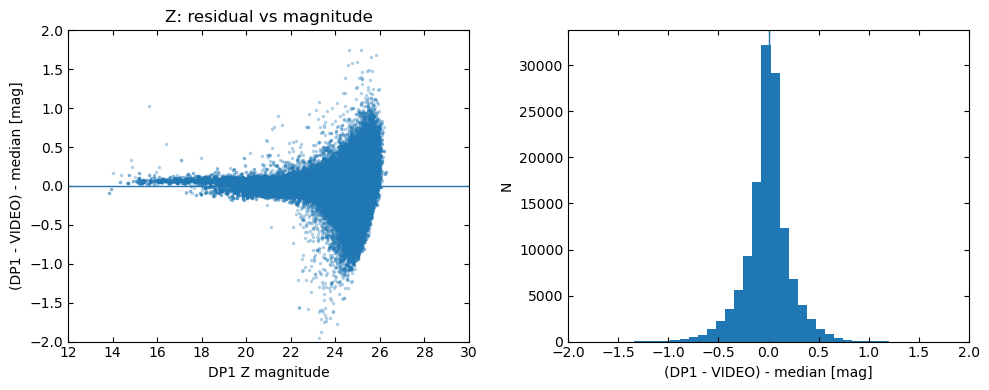

Z band
  VIDEO column: Z_MAG_APER_2
  VIDEO magErr threshold: 0.217
  N: 131253
  median(DP1 - VIDEO): 0.05926461069329747
  NMAD(res): 0.14669701422406795
  bright N (DP1 mag < 18): 612
  bright NMAD(res): 0.021201118637542597
  bright frac |res| > 0.3: 0.0196078431372549


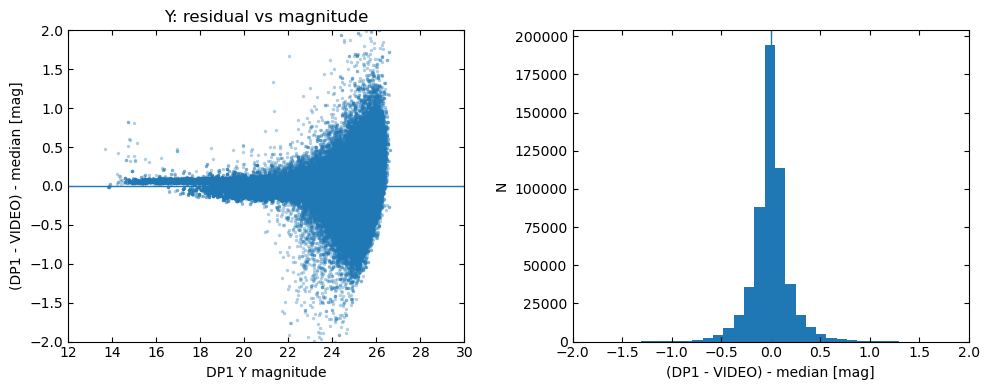

Y band
  VIDEO column: Y_MAG_APER_2
  VIDEO magErr threshold: 0.217
  N: 544187
  median(DP1 - VIDEO): 0.07472836215701761
  NMAD(res): 0.11417692785110155
  bright N (DP1 mag < 18): 2675
  bright NMAD(res): 0.01714470921481826
  bright frac |res| > 0.3: 0.0097196261682243


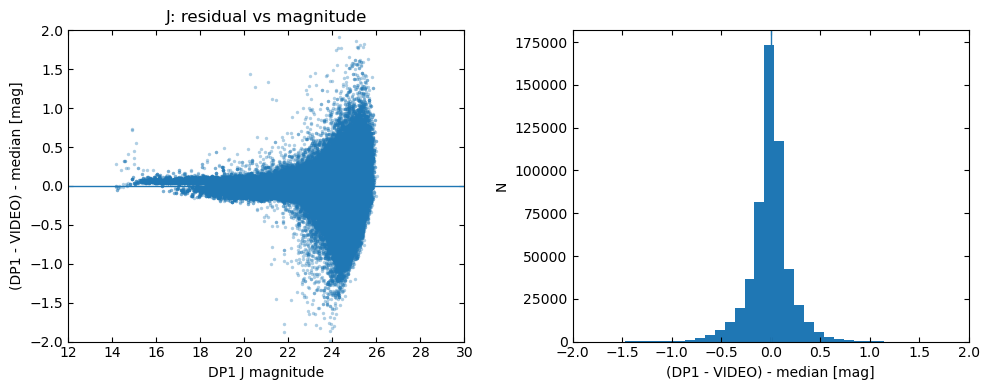

J band
  VIDEO column: J_MAG_APER_2
  VIDEO magErr threshold: 0.217
  N: 541167
  median(DP1 - VIDEO): 0.05995759837863801
  NMAD(res): 0.12458384114141932
  bright N (DP1 mag < 18): 3017
  bright NMAD(res): 0.01666669563507381
  bright frac |res| > 0.3: 0.003646005966191581


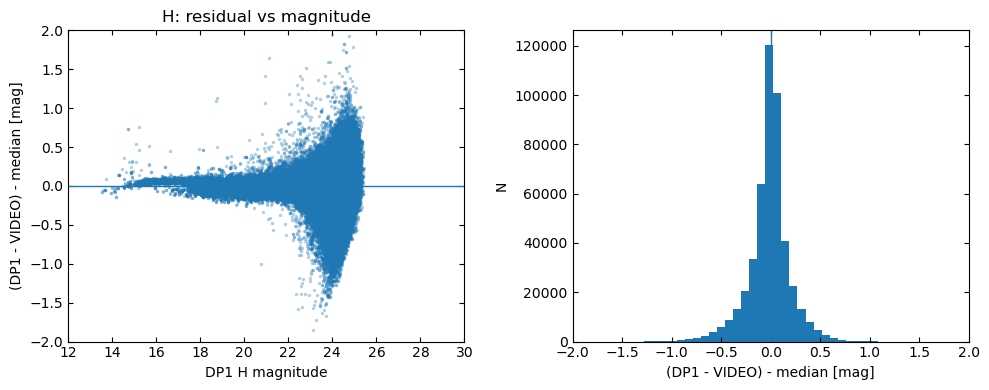

H band
  VIDEO column: H_MAG_APER_2
  VIDEO magErr threshold: 0.217
  N: 470014
  median(DP1 - VIDEO): 0.06000103863442341
  NMAD(res): 0.1291358526276137
  bright N (DP1 mag < 18): 3279
  bright NMAD(res): 0.02214180017582829
  bright frac |res| > 0.3: 0.003964623360780726


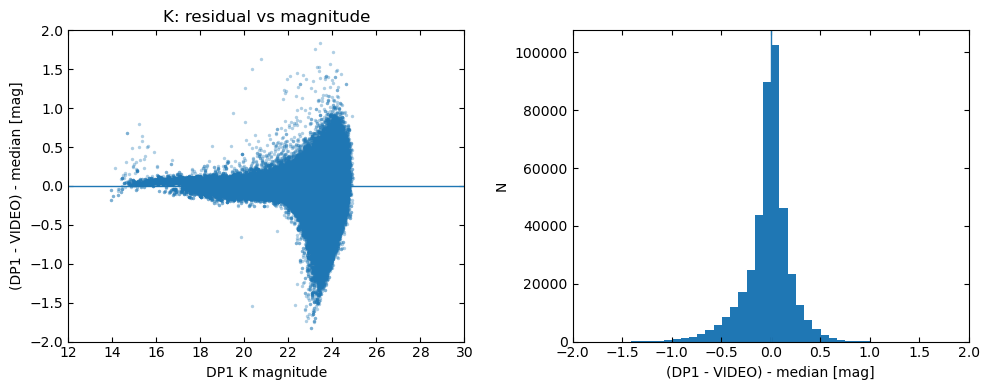

K band
  VIDEO column: KS_MAG_APER_2
  VIDEO magErr threshold: 0.217
  N: 414704
  median(DP1 - VIDEO): 0.05864123166674062
  NMAD(res): 0.13888608707711142
  bright N (DP1 mag < 18): 3407
  bright NMAD(res): 0.02544394281592684
  bright frac |res| > 0.3: 0.006163780452010567


In [5]:
def video_cols(prefix, aper=VIDEO_APER):
    return {
        "mag":  f"{prefix}_MAG_APER_{aper}",
        "err":  f"{prefix}_MAGERR_APER_{aper}",
        "flag": f"{prefix}_FLAGS",
    }


def video_good_mask(tab, prefix, aper=VIDEO_APER, err_lim=MAGERR_5SIG, require_flag=True):
    cols = video_cols(prefix, aper=aper)

    if not has_col(tab, cols["mag"]):
        raise KeyError(f"Missing VIDEO magnitude column: {cols['mag']}")

    mag = arr(tab, cols["mag"], float)

    if has_col(tab, cols["err"]):
        err = arr(tab, cols["err"], float)
        m = np.isfinite(mag) & np.isfinite(err) & (err > 0) & (err < err_lim)
    else:
        m = np.isfinite(mag)

    if require_flag and has_col(tab, cols["flag"]):
        flag = arr(tab, cols["flag"], int)
        m &= (flag == 0)

    return m


def compare_residual_band(
    band,
    aper=VIDEO_APER,
    err_lim=MAGERR_5SIG,
    xlim=(12, 30),
    ylim=(-2, 2),
):
    if band not in VIDEO_PREFIX:
        raise ValueError(f"No VIDEO mapping for band {band}")

    vprefix = VIDEO_PREFIX[band]
    vcols = video_cols(vprefix, aper=aper)

    if not has_col(vid_box, vcols["mag"]):
        print(f"Skipping {band}: missing VIDEO column {vcols['mag']}")
        return None

    dp1_m = dp1_mag(dp1c, band)
    dp1_good = dp1_band_usable(dp1c, band, snr_min=5.0)

    vid_m_all = arr(vid_box, vcols["mag"], float)
    vid_good_all = video_good_mask(vid_box, vprefix, aper=aper, err_lim=err_lim, require_flag=True)

    good = (
        matched
        & dp1_good
        & vid_good_all[idx]
        & np.isfinite(dp1_m)
        & np.isfinite(vid_m_all[idx])
    )

    if good.sum() == 0:
        print(f"{band}: no good matched sources")
        return None

    dm = dp1_m[good] - vid_m_all[idx[good]]
    const = np.nanmedian(dm)
    res = dm - const
    mag_plot = dp1_m[good]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].scatter(mag_plot, res, s=6, alpha=0.35, linewidths=0)
    axes[0].axhline(0, lw=1)
    axes[0].set_xlim(*xlim)
    axes[0].set_ylim(*ylim)
    axes[0].set_xlabel(f"DP1 {band} magnitude")
    axes[0].set_ylabel("(DP1 - VIDEO) - median [mag]")
    axes[0].set_title(f"{band}: residual vs magnitude")
    axes[0].tick_params(direction="in", top=True, right=True)

    axes[1].hist(res[np.isfinite(res)], bins=60)
    axes[1].axvline(0, lw=1)
    axes[1].set_xlim(*ylim)
    axes[1].set_xlabel("(DP1 - VIDEO) - median [mag]")
    axes[1].set_ylabel("N")
    axes[1].tick_params(direction="in", top=True, right=True)

    plt.tight_layout()
    savefig(f"dp1_video_{band}_residuals.png")
    plt.show()

    print(f"{band} band")
    print("  VIDEO column:", vcols["mag"])
    print(f"  VIDEO magErr threshold: {err_lim:.3f}")
    print("  N:", int(good.sum()))
    print("  median(DP1 - VIDEO):", float(const))
    print("  NMAD(res):", float(nmad(res)))

    bright = mag_plot < 18
    if bright.sum() > 0:
        print("  bright N (DP1 mag < 18):", int(bright.sum()))
        print("  bright NMAD(res):", float(nmad(res[bright])))
        print("  bright frac |res| > 0.3:", float(np.mean(np.abs(res[bright]) > 0.3)))

    return {
        "band": band,
        "mask": good,
        "mag": mag_plot,
        "res": res,
        "median": const,
        "nmad": nmad(res),
    }


residual_results = {}
for band in ["Z", "Y", "J", "H", "K"]:
    try:
        result = compare_residual_band(band, err_lim=MAGERR_5SIG)
        if result is not None:
            residual_results[band] = result
    except Exception as e:
        print(f"Skipping {band} because of error:")
        print(type(e).__name__, e)

### 6. Residual summary table

This table summarizes the cleaned DP1--VIDEO residual distributions in the five VIRCAM bands. The DP1 measurements use forced circular-aperture photometry with the per-band aperture and pixel-quality selection defined above, while the VIDEO measurements satisfy the corresponding catalogue-quality criteria.

In [6]:
print("Band   N       median(DP1-VIDEO)    NMAD")
for band, result in residual_results.items():
    print(
        f"{band:4s} "
        f"{len(result['res']):7d} "
        f"{result['median']:18.5f} "
        f"{result['nmad']:10.5f}"
    )

Band   N       median(DP1-VIDEO)    NMAD
Z     131253            0.05926    0.14670
Y     544187            0.07473    0.11418
J     541167            0.05996    0.12458
H     470014            0.06000    0.12914
K     414704            0.05864    0.13889


### Diagnostic check 1

The bright-source residuals are substantially tighter than the full faint-source distributions. For sources with DP1 magnitude below 18, the NMAD is approximately 0.017--0.025 mag in Y, J, H, and K, while the fraction with |residual| > 0.3 mag is below 1% in these bands. The Z band has a similarly small bright-source scatter but a slightly larger outlier fraction.

A small population of bright residual outliers nevertheless remains. The following diagnostic tests whether these cases are associated with multiple DP1 sources matched to the same VIDEO object or with relatively large positional separations.

In [7]:
# ------------------------------------------------------------
# Bright residual outlier diagnostic
# ------------------------------------------------------------

def bright_outlier_diagnostic(band, result, bright_mag_lim=18, outlier_lim=0.3):
    good = result["mask"]
    mag = result["mag"]
    res = result["res"]

    # These are arrays only for the matched-good sample,
    # so reconstruct the selected row indices.
    selected_dp1_rows = np.where(good)[0]
    selected_video_rows = idx[good]

    bright = mag < bright_mag_lim
    outlier = bright & (np.abs(res) > outlier_lim)

    print(f"\n{band} bright outlier diagnostic")
    print("N bright:", int(bright.sum()))
    print("N bright outliers:", int(outlier.sum()))
    print("fraction:", outlier.sum() / bright.sum() if bright.sum() > 0 else np.nan)

    if outlier.sum() == 0:
        return None

    dp1_rows = selected_dp1_rows[outlier]
    video_rows = selected_video_rows[outlier]

    # Check duplicate VIDEO matches
    unique_vid, counts = np.unique(video_rows, return_counts=True)
    duplicate_video_ids = unique_vid[counts > 1]
    duplicated = np.isin(video_rows, duplicate_video_ids)

    print("N outliers matched to duplicated VIDEO objects:", int(duplicated.sum()))
    print("fraction duplicated:", np.mean(duplicated))

    # Match separation
    sep_arcsec = sep[good][outlier].arcsec
    print("median separation [arcsec]:", np.nanmedian(sep_arcsec))
    print("90th percentile separation [arcsec]:", np.nanpercentile(sep_arcsec, 90))

    # Print strongest outliers
    order = np.argsort(np.abs(res[outlier]))[::-1]

    print("\nStrongest bright outliers:")
    print("DP1_row  VIDEO_row  mag  res  sep_arcsec")
    for jj in order[:20]:
        print(
            f"{dp1_rows[jj]:8d} "
            f"{video_rows[jj]:9d} "
            f"{mag[outlier][jj]:8.3f} "
            f"{res[outlier][jj]:+8.3f} "
            f"{sep_arcsec[jj]:8.3f}"
        )

    return {
        "dp1_rows": dp1_rows,
        "video_rows": video_rows,
        "res": res[outlier],
        "mag": mag[outlier],
        "sep_arcsec": sep_arcsec,
        "duplicated_video_match": duplicated,
    }


bright_outliers = {}

for band, result in residual_results.items():
    bright_outliers[band] = bright_outlier_diagnostic(band, result)


Z bright outlier diagnostic
N bright: 612
N bright outliers: 12
fraction: 0.0196078431372549
N outliers matched to duplicated VIDEO objects: 6
fraction duplicated: 0.5
median separation [arcsec]: 0.328210376135167
90th percentile separation [arcsec]: 0.45021027819217235

Strongest bright outliers:
DP1_row  VIDEO_row  mag  res  sep_arcsec
  781745    172345   16.675   +2.471    0.450
  564395    172345   16.666   +2.462    0.452
  207937    172345   16.636   +2.432    0.450
  544390    172345   16.630   +2.427    0.448
  197595    145298   16.016   +2.167    0.333
  778939    162354   15.696   +2.083    0.212
  598072    247832   15.632   +1.029    0.323
  449316    279941   16.382   +0.540    0.103
  770490    137084   17.976   +0.357    0.371
  699126    243929   17.076   +0.336    0.177
  232493    243929   17.073   +0.333    0.176
  777520    154941   14.830   +0.333    0.073

Y bright outlier diagnostic
N bright: 2675
N bright outliers: 26
fraction: 0.0097196261682243
N outliers m


- The remaining bright outliers are rare: their fraction is about 0.4--1.0% in Y, J, H, and K, while it is about 2.0% in Z. Duplicate associations with the same VIDEO object account for part of this population, but the contribution varies between bands. They represent about 57% of the K-band, 55% of the J-band, 54% of the Y-band, 50% of the Z-band, and 31% of the H-band bright outliers. Several remaining outliers also have relatively large positional separations, although ambiguous matching does not explain the full population.

The much smaller outlier fractions after applying the forced-photometry PixelFlags indicate that image-quality problems were responsible for an important part of the bright residual population present in the earlier catalogue-level selection.

### Diagnostic check 2

The bright-source residuals remain predominantly positive over part of the magnitude range, suggesting a possible magnitude-dependent trend even after the forced-photometry quality selection. The next diagnostic measures the median residual and NMAD in magnitude bins.


Z residual trend by magnitude
mag_bin        N    median_res    NMAD_res    frac_positive
14.5-15.0      11     +0.0659     0.0402      1.000
15.0-15.5      55     +0.0587     0.0211      1.000
15.5-16.0      47     +0.0646     0.0157      1.000
16.0-16.5      89     +0.0692     0.0172      1.000
16.5-17.0     104     +0.0709     0.0278      1.000
17.0-17.5     137     +0.0667     0.0165      0.971
17.5-18.0     161     +0.0704     0.0236      0.919
18.0-18.5     261     +0.0655     0.0230      0.839
18.5-19.0     343     +0.0597     0.0357      0.796
19.0-19.5     529     +0.0548     0.0358      0.790
19.5-20.0     638     +0.0546     0.0452      0.701
20.0-20.5    1011     +0.0329     0.0602      0.644
20.5-21.0    1465     +0.0132     0.0655      0.577
21.0-21.5    2313     +0.0055     0.0637      0.534
21.5-22.0    3574     +0.0019     0.0593      0.515
22.0-22.5    5416     +0.0016     0.0580      0.512
22.5-23.0    7859     +0.0033     0.0652      0.520
23.0-23.5   11155     +0.

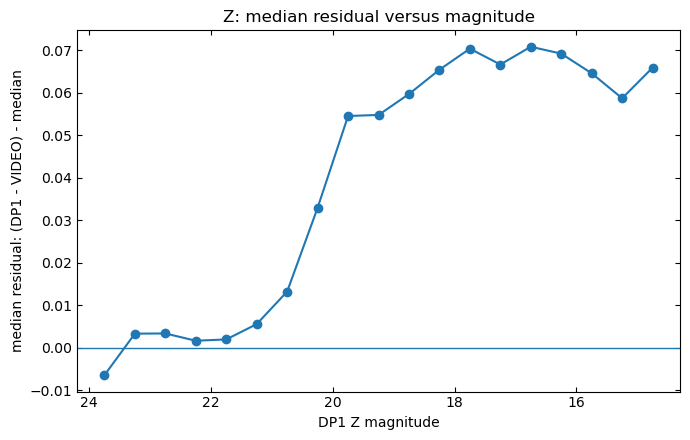

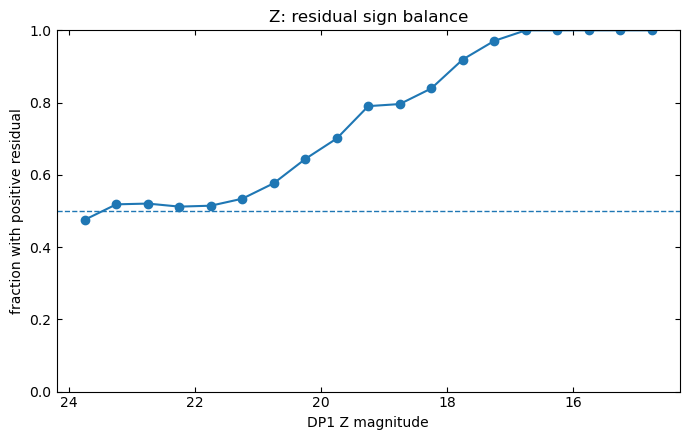


Y residual trend by magnitude
mag_bin        N    median_res    NMAD_res    frac_positive
13.5-14.0      10     -0.0034     0.0194      0.500
14.0-14.5      11     +0.0702     0.0628      1.000
14.5-15.0      86     +0.0608     0.0265      1.000
15.0-15.5     171     +0.0581     0.0198      1.000
15.5-16.0     262     +0.0610     0.0168      1.000
16.0-16.5     361     +0.0623     0.0163      1.000
16.5-17.0     483     +0.0626     0.0142      0.981
17.0-17.5     520     +0.0605     0.0175      0.942
17.5-18.0     771     +0.0610     0.0184      0.917
18.0-18.5     967     +0.0582     0.0207      0.850
18.5-19.0    1521     +0.0527     0.0277      0.728
19.0-19.5    1909     +0.0500     0.0347      0.680
19.5-20.0    2836     +0.0287     0.0647      0.566
20.0-20.5    4526     +0.0053     0.0701      0.524
20.5-21.0    7128     -0.0019     0.0649      0.494
21.0-21.5   10611     -0.0010     0.0543      0.492
21.5-22.0   15605     +0.0013     0.0514      0.508
22.0-22.5   23441     +0.

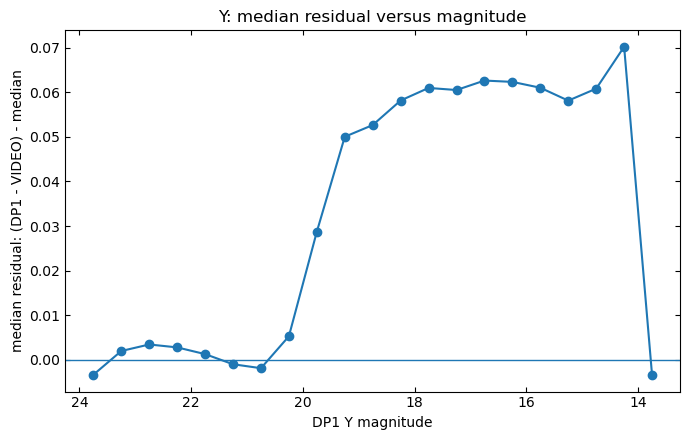

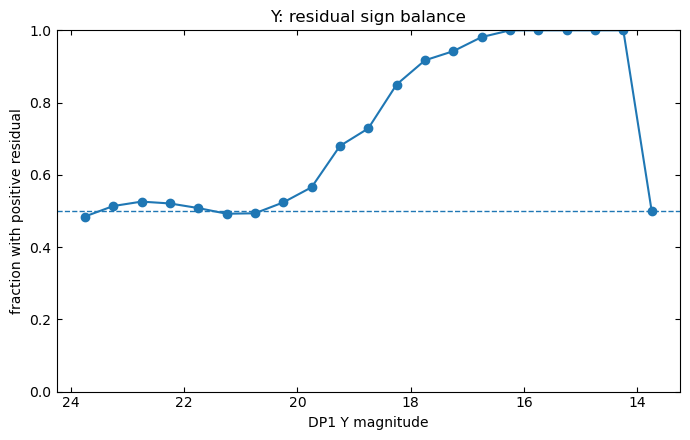


J residual trend by magnitude
mag_bin        N    median_res    NMAD_res    frac_positive
14.0-14.5      11     -0.0155     0.0199      0.273
14.5-15.0      30     +0.0944     0.1079      0.933
15.0-15.5      97     +0.0575     0.0159      1.000
15.5-16.0     259     +0.0636     0.0140      1.000
16.0-16.5     453     +0.0621     0.0131      0.987
16.5-17.0     485     +0.0628     0.0189      0.959
17.0-17.5     696     +0.0608     0.0167      0.924
17.5-18.0     986     +0.0611     0.0168      0.873
18.0-18.5    1302     +0.0572     0.0233      0.776
18.5-19.0    1865     +0.0541     0.0323      0.718
19.0-19.5    2576     +0.0422     0.0525      0.617
19.5-20.0    4056     +0.0103     0.0708      0.546
20.0-20.5    6264     +0.0029     0.0665      0.521
20.5-21.0   10114     +0.0024     0.0545      0.520
21.0-21.5   14457     +0.0053     0.0512      0.540
21.5-22.0   21532     +0.0039     0.0514      0.530
22.0-22.5   30891     +0.0059     0.0549      0.544
22.5-23.0   43514     +0.

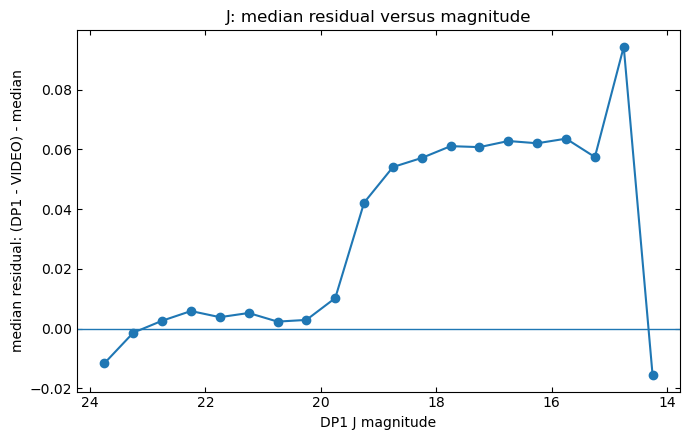

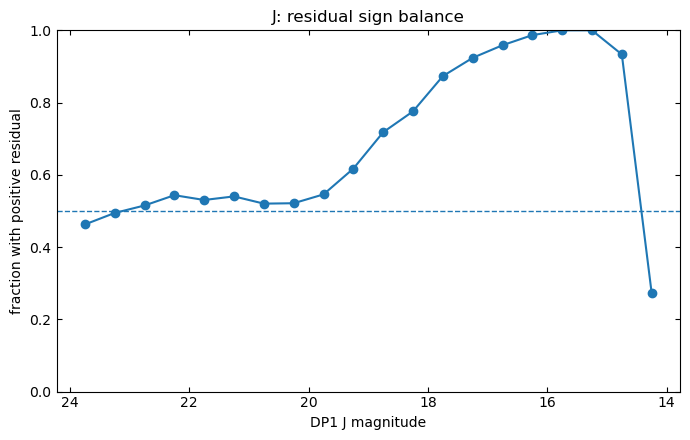


H residual trend by magnitude
mag_bin        N    median_res    NMAD_res    frac_positive
13.5-14.0      12     -0.0529     0.0390      0.083
14.0-14.5      19     -0.0294     0.0743      0.368
14.5-15.0      64     +0.0297     0.0472      0.844
15.0-15.5     221     +0.0441     0.0195      0.995
15.5-16.0     290     +0.0560     0.0162      0.986
16.0-16.5     428     +0.0564     0.0160      0.984
16.5-17.0     490     +0.0556     0.0183      0.935
17.0-17.5     747     +0.0582     0.0209      0.910
17.5-18.0    1008     +0.0548     0.0280      0.822
18.0-18.5    1505     +0.0509     0.0362      0.712
18.5-19.0    2066     +0.0424     0.0558      0.630
19.0-19.5    3077     +0.0103     0.0629      0.565
19.5-20.0    5088     +0.0050     0.0618      0.525
20.0-20.5    8261     +0.0045     0.0504      0.534
20.5-21.0   12067     +0.0086     0.0475      0.572
21.0-21.5   17483     +0.0091     0.0476      0.573
21.5-22.0   24346     +0.0082     0.0515      0.567
22.0-22.5   34662     +0.

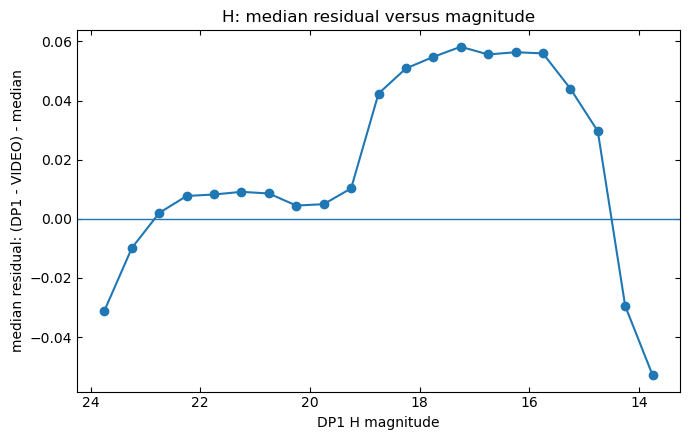

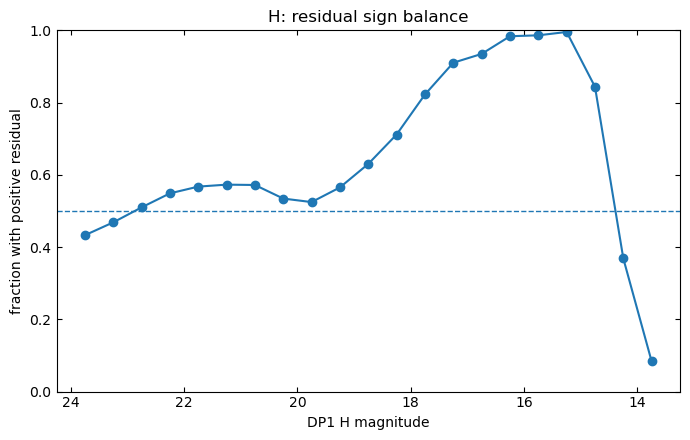


K residual trend by magnitude
mag_bin        N    median_res    NMAD_res    frac_positive
14.0-14.5      20     -0.0367     0.1156      0.350
14.5-15.0      75     +0.0393     0.0392      0.973
15.0-15.5     175     +0.0365     0.0179      0.954
15.5-16.0     291     +0.0475     0.0188      0.986
16.0-16.5     393     +0.0528     0.0199      0.977
16.5-17.0     518     +0.0529     0.0218      0.919
17.0-17.5     779     +0.0507     0.0286      0.843
17.5-18.0    1152     +0.0458     0.0324      0.766
18.0-18.5    1698     +0.0380     0.0579      0.636
18.5-19.0    2601     +0.0269     0.0599      0.596
19.0-19.5    4245     +0.0045     0.0576      0.535
19.5-20.0    7496     +0.0027     0.0492      0.525
20.0-20.5   11440     +0.0085     0.0489      0.575
20.5-21.0   16357     +0.0144     0.0476      0.625
21.0-21.5   22458     +0.0128     0.0533      0.601
21.5-22.0   30490     +0.0143     0.0664      0.587
22.0-22.5   40733     +0.0097     0.0875      0.548
22.5-23.0   57940     -0.

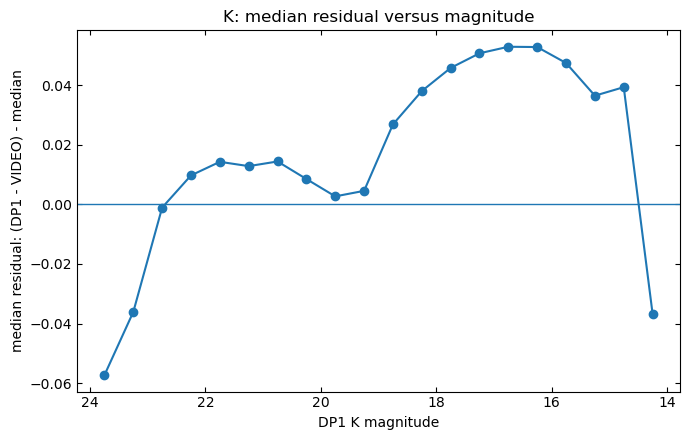

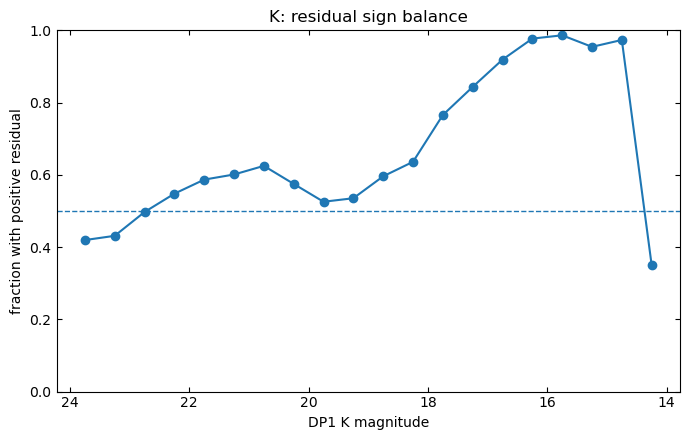

In [8]:
def residual_trend_by_mag(result, band, bins=np.arange(13, 24.5, 0.5)):
    mag = result["mag"]
    res = result["res"]

    print(f"\n{band} residual trend by magnitude")
    print("mag_bin        N    median_res    NMAD_res    frac_positive")

    bin_centres = []
    medians = []
    nmads = []
    counts = []
    frac_pos = []

    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (
            np.isfinite(mag)
            & np.isfinite(res)
            & (mag >= lo)
            & (mag < hi)
        )

        if m.sum() < 10:
            continue

        med = np.nanmedian(res[m])
        scat = nmad(res[m])
        fp = np.mean(res[m] > 0)

        bin_centres.append(0.5 * (lo + hi))
        medians.append(med)
        nmads.append(scat)
        counts.append(m.sum())
        frac_pos.append(fp)

        print(
            f"{lo:4.1f}-{hi:4.1f}  "
            f"{m.sum():6d}  "
            f"{med:+10.4f}  "
            f"{scat:9.4f}  "
            f"{fp:9.3f}"
        )

    bin_centres = np.asarray(bin_centres)
    medians = np.asarray(medians)
    nmads = np.asarray(nmads)
    frac_pos = np.asarray(frac_pos)

    plt.figure(figsize=(7, 4.5))
    plt.axhline(0, lw=1)
    plt.plot(bin_centres, medians, marker="o")
    plt.xlabel(f"DP1 {band} magnitude")
    plt.ylabel("median residual: (DP1 - VIDEO) - median")
    plt.title(f"{band}: median residual versus magnitude")
    plt.gca().invert_xaxis()
    plt.gca().tick_params(direction="in", top=True, right=True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4.5))
    plt.axhline(0.5, lw=1, ls="--")
    plt.plot(bin_centres, frac_pos, marker="o")
    plt.xlabel(f"DP1 {band} magnitude")
    plt.ylabel("fraction with positive residual")
    plt.title(f"{band}: residual sign balance")
    plt.ylim(0, 1)
    plt.gca().invert_xaxis()
    plt.gca().tick_params(direction="in", top=True, right=True)
    plt.tight_layout()
    plt.show()

    return {
        "band": band,
        "bin_centres": bin_centres,
        "median": medians,
        "nmad": nmads,
        "count": counts,
        "frac_positive": frac_pos,
    }


trend_results = {}

for band, result in residual_results.items():
    trend_results[band] = residual_trend_by_mag(result, band)


- The binned residuals show a coherent magnitude-dependent trend after the forced-photometry quality selection. In the VIRCAM bands, the bright-source residuals are predominantly positive, reaching approximately 0.04--0.06 mag over much of the 15--18 mag range. The effect is present in Y, J, H, and K, with similar behaviour also visible in Z despite its smaller bright-source sample.

- Because the plotted residual is `(DP1 - VIDEO) - median`, the positive bright-end residual indicates that the DP1 measurements are systematically fainter relative to VIDEO than the bulk catalogue at these magnitudes. The small scatter of the bright locus shows that this is a coherent magnitude-dependent effect rather than a broad photometric failure.

- Possible contributors include differences between the DP1 and VIDEO aperture definitions, source morphology and deblending, residual bright-source detector or background effects, and the limitation of representing the DP1--VIDEO relation with a single global magnitude offset. The VIDEO aperture diagnostic below provides a direct test of the first of these effects.


### 4.1 DP1--VIDEO cross-match (Stronger match-quality)
After the first residual diagnostics, some bright outliers were found to be associated with ambiguous or duplicated matches between DP1 and VIDEO. Therefore, for the main residual-validation sample I apply a stronger match-quality selection.

This cell still uses the general DP1--VIDEO matched catalogue, not a stellar-only sample. The selection starts from the nearest-neighbour DP1--VIDEO match and then applies a smaller separation threshold. For duplicated VIDEO counterparts, I keep only the closest DP1 source to that VIDEO object. This reduces ambiguous matches while keeping a representative validation sample.

In [9]:
# ------------------------------------------------------------
# Stronger match-quality test for residual plots
# ------------------------------------------------------------

def keep_closest_dp1_per_video_match(current_good_mask):
    """
    For duplicated VIDEO matches, keep only the closest DP1 source.

    This is less aggressive than removing all duplicated VIDEO matches.
    current_good_mask must have the same length as dp1c.
    """
    good_rows = np.where(current_good_mask)[0]

    video_ids = idx[current_good_mask]
    sep_values = sep.arcsec[current_good_mask]

    keep_inside = np.zeros(len(good_rows), dtype=bool)

    for video_id in np.unique(video_ids):
        members = np.where(video_ids == video_id)[0]

        # Keep the DP1 source with the smallest separation to this VIDEO object
        best_member = members[np.argmin(sep_values[members])]
        keep_inside[best_member] = True

    out = np.zeros(len(current_good_mask), dtype=bool)
    out[good_rows[keep_inside]] = True

    return out

In [10]:
DP1_RA  = "VIRCAM_K_m_coord_ra"   # radians in the DP1 table
DP1_DEC = "VIRCAM_K_m_coord_dec"  # radians in the DP1 table
VID_RA  = "RA2000"                # degrees
VID_DEC = "DEC2000"               # degrees

ra_dp1  = np.asarray(dp1[DP1_RA], dtype=float)
dec_dp1 = np.asarray(dp1[DP1_DEC], dtype=float)
m_dp1_coord = np.isfinite(ra_dp1) & np.isfinite(dec_dp1)

dp1c = dp1[m_dp1_coord]
c_dp1 = SkyCoord(
    ra=ra_dp1[m_dp1_coord] * u.rad,
    dec=dec_dp1[m_dp1_coord] * u.rad,
    frame="icrs",
)

ra_vid  = np.asarray(vid[VID_RA], dtype=float)
dec_vid = np.asarray(vid[VID_DEC], dtype=float)
m_vid_coord = np.isfinite(ra_vid) & np.isfinite(dec_vid)

vidc = vid[m_vid_coord]
c_vid = SkyCoord(
    ra=ra_vid[m_vid_coord] * u.deg,
    dec=dec_vid[m_vid_coord] * u.deg,
    frame="icrs",
)

print("Finite coordinates:")
print("  DP1  :", len(dp1c), "/", len(dp1))
print("  VIDEO:", len(vidc), "/", len(vid))

# Restrict VIDEO to the DP1 footprint for faster matching.
ra_dp1_deg = np.degrees(ra_dp1[m_dp1_coord])
dec_dp1_deg = np.degrees(dec_dp1[m_dp1_coord])

ra_min, ra_max = np.nanpercentile(ra_dp1_deg, [0.5, 99.5])
dec_min, dec_max = np.nanpercentile(dec_dp1_deg, [0.5, 99.5])

pad = 0.02
ra_min -= pad
ra_max += pad
dec_min -= pad
dec_max += pad

in_box = (
    (ra_vid[m_vid_coord] >= ra_min)
    & (ra_vid[m_vid_coord] <= ra_max)
    & (dec_vid[m_vid_coord] >= dec_min)
    & (dec_vid[m_vid_coord] <= dec_max)
)

vid_box = vidc[in_box]
c_vid_box = c_vid[in_box]

print("VIDEO rows in DP1 box:", len(vid_box))

idx, sep, _ = match_coordinates_sky(c_dp1, c_vid_box)
matched = sep < MATCH_RADIUS

print(f"Matches within {MATCH_RADIUS.to(u.arcsec).value:.2f} arcsec:", int(matched.sum()))

Finite coordinates:
  DP1  : 1477389 / 1477389
  VIDEO: 1138485 / 1138485
VIDEO rows in DP1 box: 549716
Matches within 0.50 arcsec: 810491


### 5.1 Stricter residual plots: sep < 0.35 arcsec and closest DP1 per VIDEO source

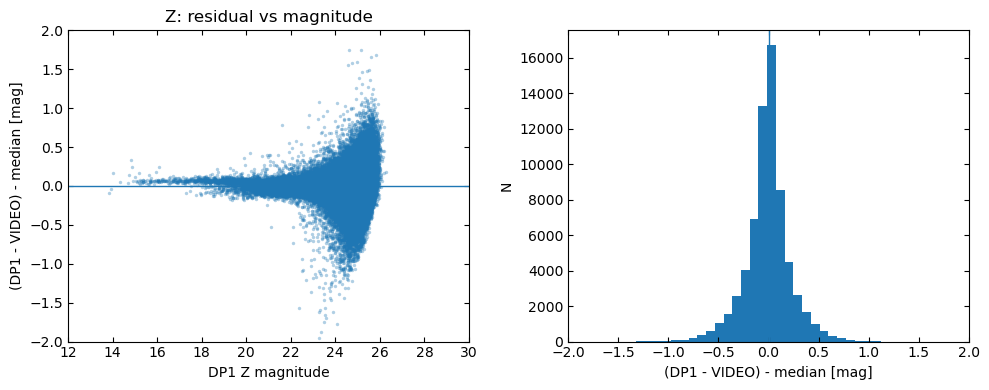

Z band
  VIDEO column: Z_MAG_APER_2
  VIDEO magErr threshold: 0.217
  N: 67412
  median(DP1 - VIDEO): 0.05977108740940551
  NMAD(res): 0.15107107667072261
  bright N (DP1 mag < 18): 223
  bright NMAD(res): 0.01853824781398776
  bright frac |res| > 0.3: 0.008968609865470852


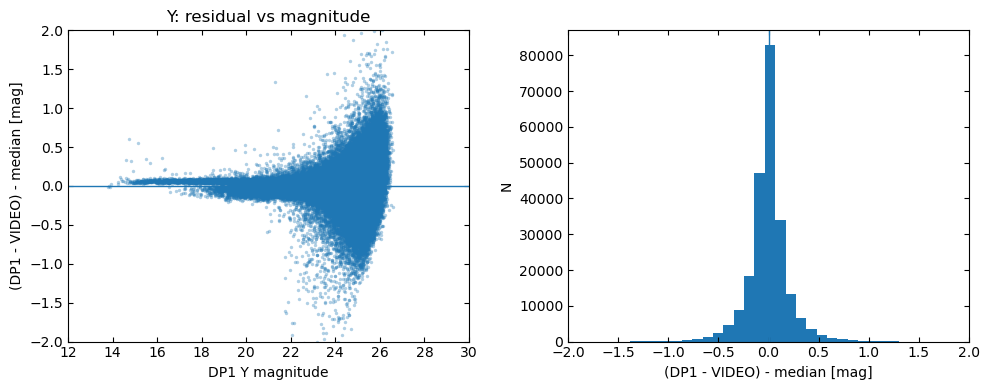

Y band
  VIDEO column: Y_MAG_APER_2
  VIDEO magErr threshold: 0.217
  N: 228446
  median(DP1 - VIDEO): 0.0753209766696834
  NMAD(res): 0.11576355655988146
  bright N (DP1 mag < 18): 855
  bright NMAD(res): 0.016889925126335713
  bright frac |res| > 0.3: 0.008187134502923977


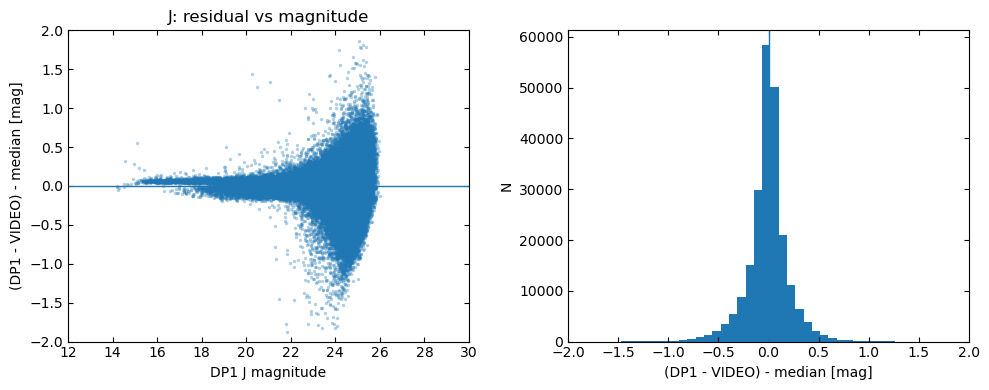

J band
  VIDEO column: J_MAG_APER_2
  VIDEO magErr threshold: 0.217
  N: 224223
  median(DP1 - VIDEO): 0.059580852730412914
  NMAD(res): 0.1268688825595239
  bright N (DP1 mag < 18): 962
  bright NMAD(res): 0.014999227650784581
  bright frac |res| > 0.3: 0.0031185031185031187


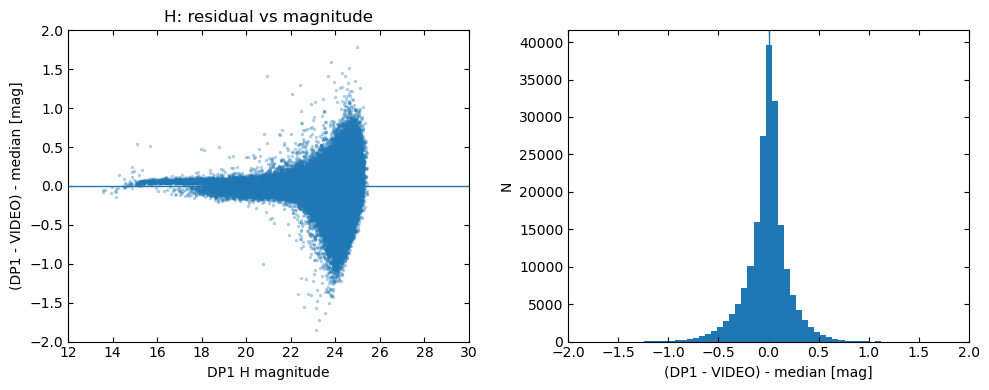

H band
  VIDEO column: H_MAG_APER_2
  VIDEO magErr threshold: 0.217
  N: 194576
  median(DP1 - VIDEO): 0.059974995969165334
  NMAD(res): 0.13083302141038844
  bright N (DP1 mag < 18): 1037
  bright NMAD(res): 0.021946876368646038
  bright frac |res| > 0.3: 0.0028929604628736743


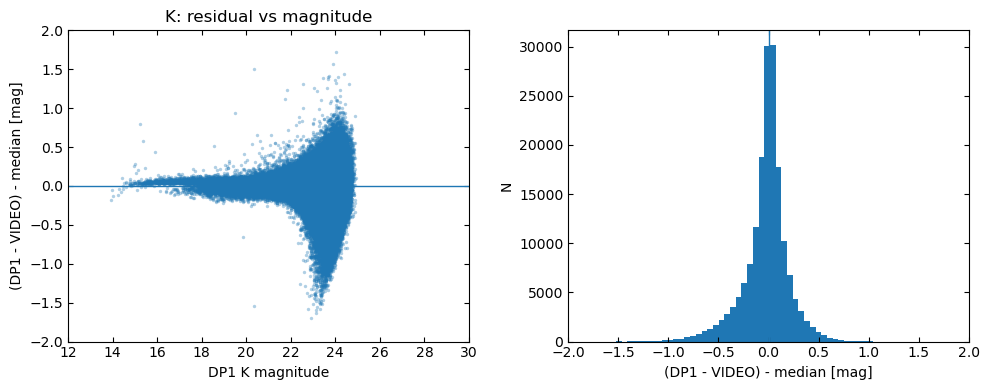

K band
  VIDEO column: KS_MAG_APER_2
  VIDEO magErr threshold: 0.217
  N: 172916
  median(DP1 - VIDEO): 0.05806794855137376
  NMAD(res): 0.14040658417448587
  bright N (DP1 mag < 18): 1083
  bright NMAD(res): 0.023961417059411502
  bright frac |res| > 0.3: 0.002770083102493075


In [11]:
def video_cols(prefix, aper=VIDEO_APER):
    return {
        "mag":  f"{prefix}_MAG_APER_{aper}",
        "err":  f"{prefix}_MAGERR_APER_{aper}",
        "flag": f"{prefix}_FLAGS",
    }


def video_good_mask(tab, prefix, aper=VIDEO_APER, err_lim=MAGERR_5SIG, require_flag=True):
    cols = video_cols(prefix, aper=aper)

    if not has_col(tab, cols["mag"]):
        raise KeyError(f"Missing VIDEO magnitude column: {cols['mag']}")

    mag = arr(tab, cols["mag"], float)

    if has_col(tab, cols["err"]):
        err = arr(tab, cols["err"], float)
        m = np.isfinite(mag) & np.isfinite(err) & (err > 0) & (err < err_lim)
    else:
        m = np.isfinite(mag)

    if require_flag and has_col(tab, cols["flag"]):
        flag = arr(tab, cols["flag"], int)
        m &= (flag == 0)

    return m


def compare_residual_band(
    band,
    aper=VIDEO_APER,
    err_lim=MAGERR_5SIG,
    xlim=(12, 30),
    ylim=(-2, 2),
):
    if band not in VIDEO_PREFIX:
        raise ValueError(f"No VIDEO mapping for band {band}")

    vprefix = VIDEO_PREFIX[band]
    vcols = video_cols(vprefix, aper=aper)

    if not has_col(vid_box, vcols["mag"]):
        print(f"Skipping {band}: missing VIDEO column {vcols['mag']}")
        return None

    dp1_m = dp1_mag(dp1c, band)
    dp1_good = dp1_band_usable(dp1c, band, snr_min=5.0,)

    vid_m_all = arr(vid_box, vcols["mag"], float)
    vid_good_all = video_good_mask(vid_box, vprefix, aper=aper, err_lim=err_lim, require_flag=True)

    good = (
        matched
        & dp1_good
        & vid_good_all[idx]
        & np.isfinite(dp1_m)
        & np.isfinite(vid_m_all[idx])
    )

    # Recommended stricter-but-not-too-aggressive validation cuts
    good &= sep.arcsec < 0.35
    good &= keep_closest_dp1_per_video_match(good)

    if good.sum() == 0:
        print(f"{band}: no good matched sources")
        return None

    dm = dp1_m[good] - vid_m_all[idx[good]]
    const = np.nanmedian(dm)
    res = dm - const
    mag_plot = dp1_m[good]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].scatter(mag_plot, res, s=6, alpha=0.35, linewidths=0)
    axes[0].axhline(0, lw=1)
    axes[0].set_xlim(*xlim)
    axes[0].set_ylim(*ylim)
    axes[0].set_xlabel(f"DP1 {band} magnitude")
    axes[0].set_ylabel("(DP1 - VIDEO) - median [mag]")
    axes[0].set_title(f"{band}: residual vs magnitude")
    axes[0].tick_params(direction="in", top=True, right=True)

    axes[1].hist(res[np.isfinite(res)], bins=60)
    axes[1].axvline(0, lw=1)
    axes[1].set_xlim(*ylim)
    axes[1].set_xlabel("(DP1 - VIDEO) - median [mag]")
    axes[1].set_ylabel("N")
    axes[1].tick_params(direction="in", top=True, right=True)

    plt.tight_layout()
    savefig(f"dp1_video_{band}_residuals.png")
    plt.show()

    print(f"{band} band")
    print("  VIDEO column:", vcols["mag"])
    print(f"  VIDEO magErr threshold: {err_lim:.3f}")
    print("  N:", int(good.sum()))
    print("  median(DP1 - VIDEO):", float(const))
    print("  NMAD(res):", float(nmad(res)))

    bright = mag_plot < 18
    if bright.sum() > 0:
        print("  bright N (DP1 mag < 18):", int(bright.sum()))
        print("  bright NMAD(res):", float(nmad(res[bright])))
        print("  bright frac |res| > 0.3:", float(np.mean(np.abs(res[bright]) > 0.3)))

    return {
        "band": band,
        "mask": good,
        "mag": mag_plot,
        "res": res,
        "median": const,
        "nmad": nmad(res),
    }


residual_results = {}
for band in ["Z", "Y", "J", "H", "K"]:
    try:
        result = compare_residual_band(band, err_lim=MAGERR_5SIG)
        if result is not None:
            residual_results[band] = result
    except Exception as e:
        print(f"Skipping {band} because of error:")
        print(type(e).__name__, e)

### 6.1 Residual summary table: stronger match-quality selection

The stricter association requires a separation below 0.35 arcsec and retains only the closest DP1 source when multiple DP1 entries are associated with the same VIDEO object. The median residuals remain very similar to those obtained with the 0.50-arcsec baseline selection, indicating that the measured DP1--VIDEO offsets are insensitive to this additional match-quality restriction. The full-sample scatter is not reduced appreciably, so this selection is retained as a robustness test rather than adopted as an additional photometric-quality requirement.


In [12]:
print("Band   N       median(DP1-VIDEO)    NMAD")
for band, result in residual_results.items():
    print(
        f"{band:4s} "
        f"{len(result['res']):7d} "
        f"{result['median']:18.5f} "
        f"{result['nmad']:10.5f}"
    )

Band   N       median(DP1-VIDEO)    NMAD
Z      67412            0.05977    0.15107
Y     228446            0.07532    0.11576
J     224223            0.05958    0.12687
H     194576            0.05997    0.13083
K     172916            0.05807    0.14041


### 7. VIDEO-star stellar-offset

This diagnostic uses a high-quality VIDEO stellar sample to examine the K-band photometric consistency between the LSST--VISTA forced photometry and the VIDEO public catalogue. VIDEO stars are matched to the DP1 catalogue using mutual nearest-neighbour matching within 0.5 arcsec.

On the DP1 side, the K-band forced circular-aperture measurement must pass the same aperture and pixel-quality selection used above and have forced-flux S/N >= 5. Primary, non-deblended catalogue entries are retained. The residuals are shown directly after placing the two catalogues on the same magnitude convention; no additional empirical stellar correction is subtracted.

VIDEO-star selection
  CLASS_STAR cut: 0.7
  N VIDEO stars : 25928

Mutual nearest-neighbour matches
  match radius: 0.5 arcsec
  N matched   : 20656
  median sep  : 0.1736237061932036 arcsec
  p90 sep     : 0.3139575279182216 arcsec

VIDEO-star residuals
  reference range       : 16.0 <= Ks < 22.0
  N stars in range      : 4799
  median in range       : 0.10873658835193467 mag
  NMAD in range         : 0.037392284580757384 mag
  full-sample N         : 7444
  full-sample median    : 0.1079246713401254 mag
  full-sample NMAD      : 0.05274345339872205 mag
16 <= Ks < 20: N= 1237, median=+0.1137, NMAD=0.0248
16 <= Ks < 21: N= 2630, median=+0.1102, NMAD=0.0299
16 <= Ks < 22: N= 4799, median=+0.1087, NMAD=0.0374
17 <= Ks < 22: N= 4694, median=+0.1084, NMAD=0.0376
18 <= Ks < 22: N= 4470, median=+0.1079, NMAD=0.0391


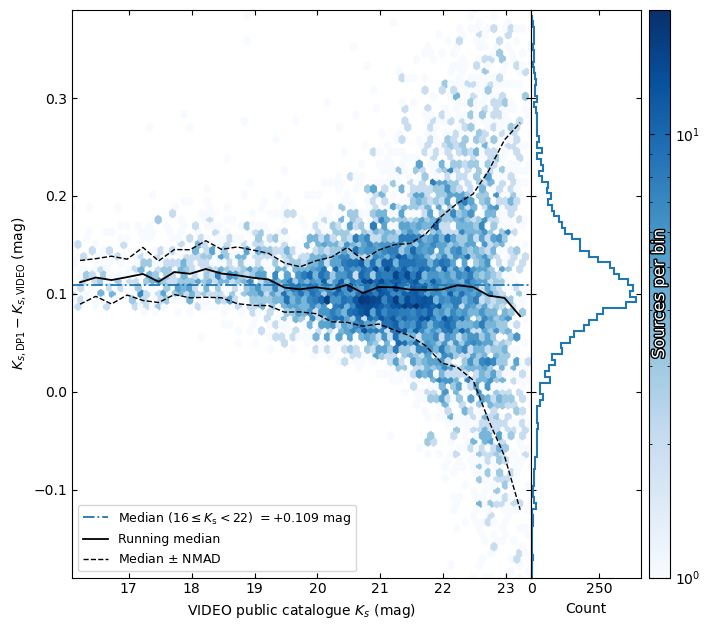

In [13]:
# ============================================================
# Final VIDEO-star K_s residual diagnostic
# ============================================================
#
# The residuals shown here are the measured DP1/VIDEO
# differences after placing both catalogues on the same
# AB magnitude convention. No additional empirical shift
# is subtracted.
#
# A well-populated stellar interval, 16 <= Ks < 22, is used
# only to quantify the characteristic median difference.
# ============================================================


MAGERR_5SIG = 2.5 / np.log(10) / 5.0
MATCH_RADIUS = 0.5 * u.arcsec
STAR_CLASS_CUT = 0.7
REFERENCE_RANGE = (16.0, 22.0)

# ------------------------------------------------------------
# VIDEO stellar selection
# ------------------------------------------------------------

ks_cls = np.asarray(
    vid_box["KS_CLASS_STAR"],
    float,
)

ks_flag = np.asarray(
    vid_box["KS_FLAGS"],
    int,
)

ks_mag = np.asarray(
    vid_box["KS_MAG_APER_2"],
    float,
)

ks_err = np.asarray(
    vid_box["KS_MAGERR_APER_2"],
    float,
)

vid_star = (
    np.isfinite(ks_cls)
    & np.isfinite(ks_mag)
    & np.isfinite(ks_err)
    & (ks_flag == 0)
    & (ks_err > 0)
    & (ks_err < MAGERR_5SIG)
    & (ks_cls > STAR_CLASS_CUT)
)

vid_star_cat = vid_box[vid_star]
c_vid_star = c_vid_box[vid_star]

print("VIDEO-star selection")
print(
    "  CLASS_STAR cut:",
    STAR_CLASS_CUT,
)
print(
    "  N VIDEO stars :",
    len(vid_star_cat),
)

# ------------------------------------------------------------
# Mutual nearest-neighbour matching
# ------------------------------------------------------------

idx_d2v, sep_d2v, _ = match_coordinates_sky(
    c_dp1,
    c_vid_star,
)

idx_v2d, sep_v2d, _ = match_coordinates_sky(
    c_vid_star,
    c_dp1,
)

video_idx = np.arange(
    len(c_vid_star)
)

dp1_idx = idx_v2d

mutual = (
    (sep_v2d < MATCH_RADIUS)
    & (idx_d2v[dp1_idx] == video_idx)
    & (sep_d2v[dp1_idx] < MATCH_RADIUS)
)

video_keep = video_idx[mutual]
dp1_keep = dp1_idx[mutual]

dp1m = dp1c[dp1_keep]
vidm = vid_star_cat[video_keep]

print("\nMutual nearest-neighbour matches")
print(
    "  match radius:",
    MATCH_RADIUS.to_value(u.arcsec),
    "arcsec",
)
print(
    "  N matched   :",
    len(dp1m),
)
print(
    "  median sep  :",
    np.median(
        sep_v2d[mutual].to_value(u.arcsec)
    ),
    "arcsec",
)
print(
    "  p90 sep     :",
    np.percentile(
        sep_v2d[mutual].to_value(u.arcsec),
        90,
    ),
    "arcsec",
)

# ------------------------------------------------------------
# DP1 and VIDEO photometry
# ------------------------------------------------------------

dp1_k_mag = dp1_mag(dp1m, "K")

dp1_k_good = dp1_band_usable(
    dp1m,
    "K",
    snr_min=5.0,
)

dp1_nchild = np.asarray(
    dp1m[
        "VIRCAM_K_m_deblend_nChild"
    ],
    int,
)

dp1_primary = np.asarray(
    dp1m[
        "VIRCAM_K_m_detect_isPrimary"
    ],
    int,
)

vid_k_mag = np.asarray(
    vidm["KS_MAG_APER_2"],
    float,
)

vid_k_err = np.asarray(
    vidm["KS_MAGERR_APER_2"],
    float,
)


# ------------------------------------------------------------
# Final photometric-quality cuts
# ------------------------------------------------------------

good = (
    dp1_k_good
    & np.isfinite(dp1_k_mag)
    & np.isfinite(vid_k_mag)
    & np.isfinite(vid_k_err)
    & (vid_k_err > 0)
    & (vid_k_err < MAGERR_5SIG)
    & (dp1_primary == 1)
    & (dp1_nchild == 0)
)

x = vid_k_mag[good]

y_raw = (
    dp1_k_mag[good]
    - vid_k_mag[good]
)

# No empirical stellar residual is subtracted
y = y_raw.copy()


# ------------------------------------------------------------
# Reference stellar interval
# ------------------------------------------------------------

reference_mask = (
    np.isfinite(x)
    & np.isfinite(y)
    & (x >= REFERENCE_RANGE[0])
    & (x < REFERENCE_RANGE[1])
)

reference_median = np.nanmedian(
    y[reference_mask]
)

reference_nmad = nmad(
    y[reference_mask]
)


REFERENCE_RANGE = (16.0, 22.0)

# ------------------------------------------------------------
# Reference stellar interval
# ------------------------------------------------------------

reference_mask = (
    np.isfinite(x)
    & np.isfinite(y_raw)
    & (x >= REFERENCE_RANGE[0])
    & (x < REFERENCE_RANGE[1])
)

if reference_mask.sum() < 20:
    raise RuntimeError(
        f"Too few stars in reference range {REFERENCE_RANGE}: "
        f"N={reference_mask.sum()}"
    )

reference_median = np.nanmedian(y_raw[reference_mask])
reference_nmad = nmad(y_raw[reference_mask])

# Keep the measured residuals unchanged
y = y_raw.copy()

print("\nVIDEO-star residuals")
print(
    f"  reference range       : "
    f"{REFERENCE_RANGE[0]} <= Ks < {REFERENCE_RANGE[1]}"
)
print(
    "  N stars in range      :",
    int(reference_mask.sum()),
)
print(
    "  median in range       :",
    float(reference_median),
    "mag",
)
print(
    "  NMAD in range         :",
    float(reference_nmad),
    "mag",
)
print(
    "  full-sample N         :",
    int(np.isfinite(y).sum()),
)
print(
    "  full-sample median    :",
    float(np.nanmedian(y)),
    "mag",
)
print(
    "  full-sample NMAD      :",
    float(nmad(y)),
    "mag",
)


for lo, hi in [
    (16, 20),
    (16, 21),
    (16, 22),
    (17, 22),
    (18, 22),
]:
    m = (
        np.isfinite(x)
        & np.isfinite(y_raw)
        & (x >= lo)
        & (x < hi)
    )

    print(
        f"{lo:2.0f} <= Ks < {hi:2.0f}: "
        f"N={m.sum():5d}, "
        f"median={np.nanmedian(y_raw[m]):+.4f}, "
        f"NMAD={nmad(y_raw[m]):.4f}"
    )

# ------------------------------------------------------------
# Running statistics for this figure
# ------------------------------------------------------------

def stellar_running_stats(x, y, bin_edges, min_per_bin=10):
    xc = []
    med = []
    scat = []

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        sel = (
            np.isfinite(x)
            & np.isfinite(y)
            & (x >= lo)
            & (x < hi)
        )

        if np.sum(sel) < min_per_bin:
            continue

        yy = y[sel]

        xc.append(0.5 * (lo + hi))
        med.append(np.nanmedian(yy))
        scat.append(nmad(yy))

    return (
        np.asarray(xc),
        np.asarray(med),
        np.asarray(scat),
    )


xlim = (16.1, 23.4)
ylim = (-0.19, 0.39)

bin_edges = np.arange(
    xlim[0],
    xlim[1] + 0.0001,
    0.25,
)

xc, ymed, ysig = stellar_running_stats(
    x,
    y,
    bin_edges,
    min_per_bin=10,
)

# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------

fig = plt.figure(figsize=(7.2, 6.4))
ax = fig.add_subplot(111)

divider = make_axes_locatable(ax)

ax_r = divider.append_axes(
    "right",
    size=1.1,
    pad=0.0,
    sharey=ax,
)

cax = divider.append_axes(
    "right",
    size="4.5%",
    pad=0.08,
)

# ------------------------------------------------------------
# Main density plot
# ------------------------------------------------------------

hb = ax.hexbin(
    x,
    y,
    gridsize=80,
    extent=(
        xlim[0],
        xlim[1],
        ylim[0],
        ylim[1],
    ),
    mincnt=1,
    bins="log",
    cmap="Blues",
)

# Median measured from the reference stellar interval
ax.axhline(
    reference_median,
    lw=1.3,
    ls="-.",
    label=(
        rf"Median ($16\leq K_{{\rm s}}<22$) "
        rf"$= {reference_median:+.3f}$ mag"
    ),
)

# Running median and scatter
ax.plot(
    xc,
    ymed,
    lw=1.3,
    color="black",
    label="Running median",
)

ax.plot(
    xc,
    ymed + ysig,
    lw=1.0,
    ls="--",
    color="black",
    label=r"Median $\pm$ NMAD",
)

ax.plot(
    xc,
    ymed - ysig,
    lw=1.0,
    ls="--",
    color="black",
)

# ------------------------------------------------------------
# Main-axis formatting
# ------------------------------------------------------------

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax.set_xlabel(
    r"VIDEO public catalogue $K_s$ (mag)",
    fontsize=10,
)

ax.set_ylabel(
    r"$K_{s,\mathrm{DP1}} - K_{s,\mathrm{VIDEO}}$ (mag)",
    fontsize=10
)

ax.tick_params(
    direction="in",
    top=True,
    right=True,
)

ax.legend(
    loc="lower left",
    frameon=True,
    fontsize=9,
)

# ------------------------------------------------------------
# Marginal residual histogram
# ------------------------------------------------------------

bins_y = np.linspace(
    ylim[0],
    ylim[1],
    100,
)

ax_r.hist(
    y,
    bins=bins_y,
    histtype="step",
    lw=1.5,
    orientation="horizontal",
)

ax_r.tick_params(
    direction="in",
    top=True,
    right=True,
    labelleft=False,
)

ax_r.set_xlabel("Count")

# Full-sample statistics
txt = (
    rf"$N = {np.isfinite(y).sum()}$"
    "\n"
    rf"median $= {np.nanmedian(y):+.3f}$"
    "\n"
    rf"$\sigma_{{\rm NMAD}} = {nmad(y):.3f}$"
)



# ------------------------------------------------------------
# Colour bar
# ------------------------------------------------------------

cb = fig.colorbar(
    hb,
    cax=cax,
)

cb.ax.tick_params(
    which="both",
    direction="in",
    right=True,
    left=True,
)

cb.set_label("")

cb.ax.text(
    0.5,
    0.5,
    "Sources per bin",
    transform=cb.ax.transAxes,
    rotation=90,
    ha="center",
    va="center",
    color="white",
    fontsize=12,
    path_effects=[
        pe.withStroke(
            linewidth=2,
            foreground="black",
        )
    ],
)

plt.tight_layout()
fig.savefig(
    OUTDIR / "dp1_video_stars_residuals.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.show()

This diagnostic evaluates the stellar photometric consistency between the LSST-VISTA Fusion Pipeline forced photometry and the VIDEO public catalogue in the Ks band.

The comparison is restricted to a clean stellar sample from VIDEO. VIDEO stars are selected using `KS_CLASS_STAR > 0.7`, `KS_FLAGS = 0`, finite `KS_MAG_APER_2` and `KS_MAGERR_APER_2`, positive magnitude errors, and `KS_MAGERR_APER_2 < 0.217`, corresponding approximately to a 5-sigma photometric-error cut. The VIDEO stellar catalogue is then matched to the DP1 catalogue using mutual nearest-neighbour matching within 0.5 arcsec, retaining one-to-one VIDEO-star/DP1 associations.

On the DP1 side, the comparison uses the forced `VIRCAM_K_f_base_CircularApertureFlux_6_0` photometry. Measurements are required to pass the forced-photometry aperture and pixel-quality selection defined above and to have S/N >= 5. The sample is further restricted to `detect_isPrimary = 1` and `deblend_nChild = 0`.

After these selections, the final sample contains 7,444 matched stars. No additional empirical shift is subtracted from the residuals. Over the well-populated interval `16 <= Ks < 22`, 4,799 stars give a median DP1-VIDEO residual of +0.109 mag and an NMAD of 0.037 mag. For the full stellar sample, the median residual is +0.108 mag and the NMAD is 0.053 mag.

The stellar median should not be interpreted as a pure photometric zero-point offset because the DP1 and VIDEO aperture definitions are not identical. The following aperture-choice diagnostic tests the sensitivity of the measured residual to the adopted VIDEO aperture.

### 7.1 VIDEO aperture-choice diagnostic for the stellar sample

The same matched stellar sample is used to test how the raw DP1-VIDEO residual depends on the adopted VIDEO aperture. The DP1 measurement remains the forced K-band circular-aperture flux with the same photometric and pixel-quality selection used above, while several VIDEO `KS_MAG_APER_*` measurements are compared.

This is a diagnostic of aperture dependence rather than an additional photometric correction. A change in the median residual with VIDEO aperture size indicates that part of the DP1-VIDEO difference arises from the different aperture definitions rather than solely from photometric calibration.

DP1 stellar quality base sample
  N matched stellar rows : 20656
  N after DP1 K cuts     : 7444


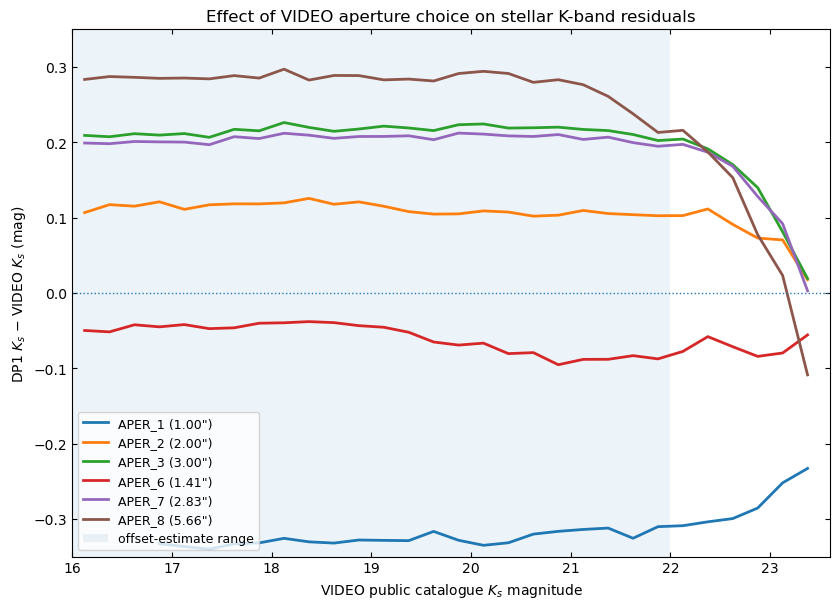


VIDEO aperture-choice summary
Shift-summary range: 16.0 <= Ks < 22.0

aper  diam   N_all   med_all  nmad_all   N_shift  med_shift  nmad_shift
   1  1.00    1810   -0.3064    0.0449       809    -0.3242      0.0246
   2  2.00    7179   +0.1065    0.0511      4782    +0.1086      0.0371
   3  3.00    6803   +0.2121    0.0498      4910    +0.2172      0.0393
   6  1.41    7257   -0.0721    0.0746      4407    -0.0717      0.0593
   7  2.83    6879   +0.2017    0.0484      4915    +0.2059      0.0381
   8  5.66    5044   +0.2690    0.0627      3843    +0.2794      0.0464


In [14]:
# ============================================================
# VIDEO aperture-choice diagnostic for the matched stellar sample
# ============================================================
#   dp1m : matched DP1 sources
#   vidm : matched VIDEO stars
#
# The purpose is to see how the raw DP1 - VIDEO residual changes
# when different VIDEO aperture magnitudes are used.

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def nmad(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    med = np.nanmedian(x)
    return 1.4826 * np.nanmedian(np.abs(x - med))


def running_stats(x, y, bin_edges, min_per_bin=10):
    xc, med, scat, nbin = [], [], [], []

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        m = (
            np.isfinite(x)
            & np.isfinite(y)
            & (x >= lo)
            & (x < hi)
        )

        if m.sum() < min_per_bin:
            continue

        yy = y[m]

        xc.append(0.5 * (lo + hi))
        med.append(np.nanmedian(yy))
        scat.append(nmad(yy))
        nbin.append(m.sum())

    return (
        np.asarray(xc),
        np.asarray(med),
        np.asarray(scat),
        np.asarray(nbin),
    )


def optional_bool_column(tab, col, default=True):
    if col in tab.colnames:
        return np.asarray(tab[col], bool)
    return np.full(len(tab), default, dtype=bool)


def optional_int_column(tab, col, default=0):
    if col in tab.colnames:
        return np.asarray(tab[col], int)
    return np.full(len(tab), default, dtype=int)


# ------------------------------------------------------------
# Check that this cell is run after the stellar-match cell
# ------------------------------------------------------------

for required_name in ["dp1m", "vidm"]:
    if required_name not in globals():
        raise RuntimeError(
            f"`{required_name}` is not defined. "
            "Run the VIDEO-star stellar-offset cell first."
        )


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

MAGERR_5SIG = 2.5 / np.log(10) / 5.0

# Safe stellar range used for offset summaries
SHIFT_RANGE = (16.0, 22.0)

# Plot range
XLIM = (16.0, 23.6)
YLIM = (-0.35, 0.35)

# VIDEO aperture numbers and approximate aperture diameters in arcsec.
# These labels are used only for the legend.
apertures = {
    1: 1.00,
    2: 2.00,
    3: 3.00,
    6: 1.41,
    7: 2.83,
    8: 5.66,
}


# ------------------------------------------------------------
# DP1 K-band quality selection
# ------------------------------------------------------------

dp1_k_mag = dp1_mag(dp1m, "K")

dp1_primary = optional_bool_column(
    dp1m,
    "VIRCAM_K_m_detect_isPrimary",
    default=True,
)

dp1_nchild = optional_int_column(
    dp1m,
    "VIRCAM_K_m_deblend_nChild",
    default=0,
)

base_dp1 = (
    dp1_band_usable(
        dp1m,
        "K",
        snr_min=5.0,
    )
    & dp1_primary
    & (dp1_nchild == 0)
)

print("DP1 stellar quality base sample")
print("  N matched stellar rows :", len(dp1m))
print("  N after DP1 K cuts     :", int(base_dp1.sum()))

# ------------------------------------------------------------
# Compare different VIDEO apertures
# ------------------------------------------------------------

summary_rows = []

fig, ax = plt.subplots(figsize=(8.5, 6.2))

bin_edges = np.arange(XLIM[0], XLIM[1] + 0.001, 0.25)

for aper, diam in apertures.items():

    mag_col = f"KS_MAG_APER_{aper}"
    err_col = f"KS_MAGERR_APER_{aper}"

    if mag_col not in vidm.colnames or err_col not in vidm.colnames:
        print(f"Skipping APER_{aper}: missing {mag_col} or {err_col}")
        continue

    vid_mag = np.asarray(vidm[mag_col], float)
    vid_err = np.asarray(vidm[err_col], float)

    good = (
        base_dp1
        & np.isfinite(vid_mag)
        & np.isfinite(vid_err)
        & (vid_err > 0)
        & (vid_err < MAGERR_5SIG)
    )

    x = vid_mag[good]
    y = dp1_k_mag[good] - vid_mag[good]

    # Restrict only the plotted/statistical range.
    use = (
        np.isfinite(x)
        & np.isfinite(y)
        & (x >= XLIM[0])
        & (x <= XLIM[1])
        & (y >= YLIM[0])
        & (y <= YLIM[1])
    )

    x = x[use]
    y = y[use]

    if len(y) < 30:
        print(f"Skipping APER_{aper}: too few usable stars")
        continue

    xc, ymed, ysig, nbin = running_stats(
        x,
        y,
        bin_edges,
        min_per_bin=10,
    )

    ax.plot(
        xc,
        ymed,
        lw=2,
        label=f"APER_{aper} ({diam:.2f}\")",
    )

    shift_mask = (
        np.isfinite(x)
        & np.isfinite(y)
        & (x >= SHIFT_RANGE[0])
        & (x < SHIFT_RANGE[1])
    )

    summary_rows.append(
        {
            "aper": aper,
            "diam": diam,
            "N_all": len(y),
            "med_all": np.nanmedian(y),
            "nmad_all": nmad(y),
            "N_shift": int(shift_mask.sum()),
            "med_shift": np.nanmedian(y[shift_mask]) if shift_mask.sum() else np.nan,
            "nmad_shift": nmad(y[shift_mask]) if shift_mask.sum() else np.nan,
        }
    )


# ------------------------------------------------------------
# Plot formatting
# ------------------------------------------------------------

ax.axhline(0, lw=1.0, ls=":")
ax.axvspan(
    SHIFT_RANGE[0],
    SHIFT_RANGE[1],
    alpha=0.08,
    label="offset-estimate range",
)

ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)

ax.set_xlabel("VIDEO public catalogue $K_s$ magnitude")
ax.set_ylabel("DP1 $K_s$ − VIDEO $K_s$ (mag)")
ax.set_title("Effect of VIDEO aperture choice on stellar K-band residuals")
ax.tick_params(direction="in", top=True, right=True)
ax.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

print()
print("VIDEO aperture-choice summary")
print(f"Shift-summary range: {SHIFT_RANGE[0]} <= Ks < {SHIFT_RANGE[1]}")
print()
print("aper  diam   N_all   med_all  nmad_all   N_shift  med_shift  nmad_shift")

for row in summary_rows:
    print(
        f"{row['aper']:>4d}  "
        f"{row['diam']:>4.2f}  "
        f"{row['N_all']:>6d}  "
        f"{row['med_all']:>+8.4f}  "
        f"{row['nmad_all']:>8.4f}  "
        f"{row['N_shift']:>8d}  "
        f"{row['med_shift']:>+9.4f}  "
        f"{row['nmad_shift']:>10.4f}"
    )

- The aperture-choice diagnostic shows a strong dependence of the raw DP1--VIDEO stellar residual on the VIDEO aperture definition. Over `16 <= Ks < 22`, the median residual changes from approximately -0.072 mag for the 1.41-arcsec VIDEO aperture to +0.109 mag for the adopted 2.0-arcsec aperture and +0.206 mag for the 2.83-arcsec aperture. The approximately 0.11-mag difference measured with `KS_MAG_APER_2` therefore contains a substantial aperture-dependent component and should not be interpreted as a pure photometric zero-point offset.

### 8. Magnitude-distribution comparison

The magnitude distributions provide an additional comparison between the DP1 forced photometry and the VIDEO catalogue. The full cleaned samples compare the independently selected DP1 and VIDEO populations, while the matched samples contain only positional associations with separation below 0.35 arcsec, retaining the closest DP1 source for duplicated VIDEO counterparts.

These distributions are diagnostic comparisons rather than completeness measurements.

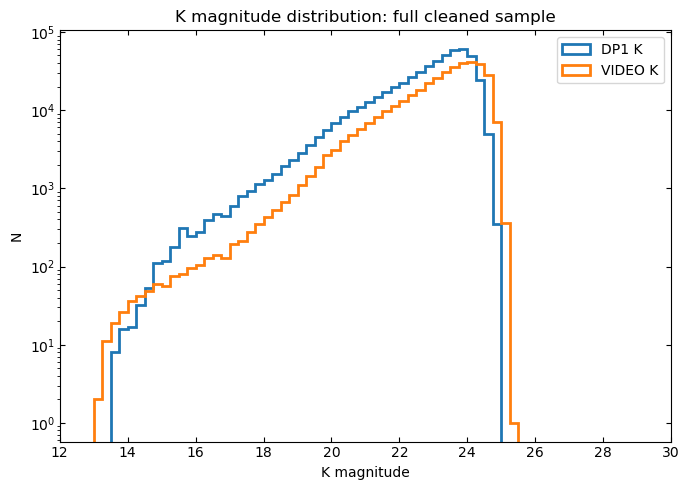

K histogram mode: full cleaned sample
DP1 K N: 537596
VIDEO K N: 382234


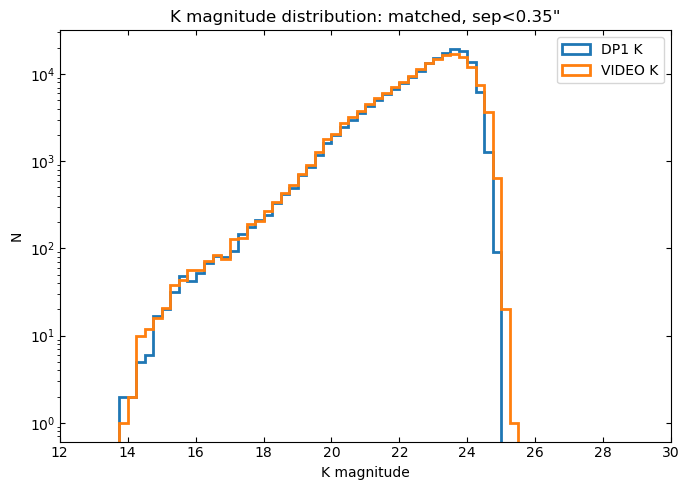

K histogram mode: matched, sep<0.35"
DP1 K N: 172916
VIDEO K N: 172916


In [15]:
def plot_histogram_comparison(
    band,
    aper=VIDEO_APER,
    err_lim=MAGERR_5SIG,
    matched_only=False,
    match_sep_arcsec=0.35,
    keep_closest_match=True,
):
    if band not in VIDEO_PREFIX:
        raise ValueError(f"No VIDEO mapping for {band}")

    vprefix = VIDEO_PREFIX[band]
    vcols = video_cols(vprefix, aper=aper)

    dp1_m = dp1_mag(dp1c, band)
    dp1_good = dp1_band_usable(
        dp1c,
        band,
        snr_min=5.0,
    )

    vid_m_all = arr(vid_box, vcols["mag"], float)
    vid_good_all = video_good_mask(
        vid_box,
        vprefix,
        aper=aper,
        err_lim=err_lim,
        require_flag=True,
    )

    if matched_only:
        # Same logic as residual-validation sample
        good = (
            matched
            & dp1_good
            & vid_good_all[idx]
            & np.isfinite(dp1_m)
            & np.isfinite(vid_m_all[idx])
        )

        if match_sep_arcsec is not None:
            good &= sep.arcsec < match_sep_arcsec

        if keep_closest_match:
            good &= keep_closest_dp1_per_video_match(good)

        dp1_plot = dp1_m[good]
        vid_plot = vid_m_all[idx[good]]

        label_suffix = (
            f"matched, sep<{match_sep_arcsec:.2f}\""
            if match_sep_arcsec is not None
            else "matched"
        )

    else:
        # Full cleaned catalogue comparison, not matched one-to-one
        dp1_plot = dp1_m[dp1_good & np.isfinite(dp1_m)]
        vid_plot = vid_m_all[vid_good_all & np.isfinite(vid_m_all)]

        label_suffix = "full cleaned sample"

    bins = np.arange(12, 30.1, 0.25)

    plt.figure(figsize=(7, 5))

    plt.hist(
        dp1_plot,
        bins=bins,
        histtype="step",
        lw=2,
        label=f"DP1 {band}",
    )

    plt.hist(
        vid_plot,
        bins=bins,
        histtype="step",
        lw=2,
        label=f"VIDEO {band}",
    )

    plt.xlabel(f"{band} magnitude")
    plt.ylabel("N")
    plt.title(f"{band} magnitude distribution: {label_suffix}")
    plt.yscale("log")
    plt.legend()

    ax = plt.gca()
    ax.set_xlim(12, 30)
    ax.tick_params(direction="in", top=True, right=True)

    plt.tight_layout()

    if matched_only:
        savefig(f"dp1_video_{band}_histogram_matched.png")
    else:
        savefig(f"dp1_video_{band}_histogram_full_cleaned.png")

    plt.show()

    print(f"{band} histogram mode:", label_suffix)
    print(f"DP1 {band} N:", int(len(dp1_plot)))
    print(f"VIDEO {band} N:", int(len(vid_plot)))

plot_histogram_comparison("K", matched_only=False)
plot_histogram_comparison("K", matched_only=True, match_sep_arcsec=0.35)

### Useful extra check

This count ladder shows how the K-band validation sample changes after the photometric-quality selection, positional matching, the stricter 0.35-arcsec separation cut, and the closest-match requirement.

In [16]:
def match_count_ladder(band, aper=VIDEO_APER, err_lim=MAGERR_5SIG):
    vprefix = VIDEO_PREFIX[band]
    vcols = video_cols(vprefix, aper=aper)

    dp1_m = dp1_mag(dp1c, band)
    dp1_good = dp1_band_usable(dp1c, band, snr_min=5.0,)

    vid_m_all = arr(vid_box, vcols["mag"], float)
    vid_good_all = video_good_mask(
        vid_box, vprefix, aper=aper, err_lim=err_lim, require_flag=True
    )

    base = (
        matched
        & dp1_good
        & vid_good_all[idx]
        & np.isfinite(dp1_m)
        & np.isfinite(vid_m_all[idx])
    )

    sep05 = base & (sep.arcsec < 0.50)
    sep035 = base & (sep.arcsec < 0.35)

    closest035 = sep035 & keep_closest_dp1_per_video_match(sep035)

    print(f"{band} count ladder")
    print("Full cleaned DP1       :", int((dp1_good & np.isfinite(dp1_m)).sum()))
    print("Full cleaned VIDEO     :", int((vid_good_all & np.isfinite(vid_m_all)).sum()))
    print("Matched, sep < 0.50    :", int(sep05.sum()))
    print("Matched, sep < 0.35    :", int(sep035.sum()))
    print("sep < 0.35 + closest   :", int(closest035.sum()))

match_count_ladder("K")

K count ladder
Full cleaned DP1       : 537596
Full cleaned VIDEO     : 382234
Matched, sep < 0.50    : 414704
Matched, sep < 0.35    : 371429
sep < 0.35 + closest   : 172916


- The separation cut from 0.50 to 0.35 arcsec removes only about 10% of the matched K-band sample. The much larger reduction occurs when only the closest DP1 source associated with each VIDEO object is retained, reducing the sample from 371,429 to 172,916 sources. This indicates that many DP1 sources share the same nearest VIDEO counterpart, consistent with differences in resolution and deblending between the catalogues. The closest-match requirement is therefore useful as a strict matching diagnostic, but is too aggressive for the main catalogue-level photometric comparison.


### 9. Colour-colour plots

Each colour-colour diagnostic requires clean forced photometry only in the bands used to construct the two colours. The aperture and selected pixel-quality flags are applied independently in each contributing band, together with forced-flux S/N >= 5.

In [17]:
from matplotlib.colors import LogNorm


def colour_plot_mask(
    x_bands,
    y_bands,
    xlim=None,
    ylim=None,
    snr_min=5.0,
):

    used_bands = sorted(
        set(list(x_bands) + list(y_bands))
    )

    mask = np.ones(
        len(dp1c),
        dtype=bool,
    )

    for band in used_bands:
        mask &= dp1_band_usable(
            dp1c,
            band,
            snr_min=snr_min,
        )

    x = dp1_colour(
        dp1c,
        x_bands[0],
        x_bands[1],
    )

    y = dp1_colour(
        dp1c,
        y_bands[0],
        y_bands[1],
    )

    mask &= (
        np.isfinite(x)
        & np.isfinite(y)
    )

    if xlim is not None:
        mask &= (
            (x > xlim[0])
            & (x < xlim[1])
        )

    if ylim is not None:
        mask &= (
            (y > ylim[0])
            & (y < ylim[1])
        )

    return x, y, mask


def plot_colour_colour(
    x_bands,
    y_bands,
    xlim,
    ylim,
    title,
    bins=180,
    snr_min=5.0,
):

    x, y, mask = colour_plot_mask(
        x_bands,
        y_bands,
        xlim=xlim,
        ylim=ylim,
        snr_min=snr_min,
    )

    print("\n" + title)
    print(
        "  bands used:",
        sorted(
            set(
                list(x_bands)
                + list(y_bands)
            )
        ),
    )
    print(
        "  N selected:",
        int(mask.sum()),
    )

    plt.figure(figsize=(6.5, 6))

    plt.hist2d(
        x[mask],
        y[mask],
        bins=bins,
        range=[xlim, ylim],
        cmap="Greys",
        cmin=1,
        norm=LogNorm(vmin=1),
    )

    plt.xlabel(
        f"{x_bands[0]} - {x_bands[1]}"
    )
    plt.ylabel(
        f"{y_bands[0]} - {y_bands[1]}"
    )
    plt.title(title)

    plt.colorbar(
        label="Number of sources"
    )

    plt.gca().tick_params(
        direction="in",
        top=True,
        right=True,
    )

    plt.tight_layout()

    fname = (
        title.lower()
        .replace(" ", "_")
        .replace(":", "")
        .replace("/", "_")
        + ".png"
    )

    savefig(fname)

    plt.show()

    return mask


Clean colour-colour: g-i versus J-K
  bands used: ['J', 'K', 'g', 'i']
  N selected: 107210


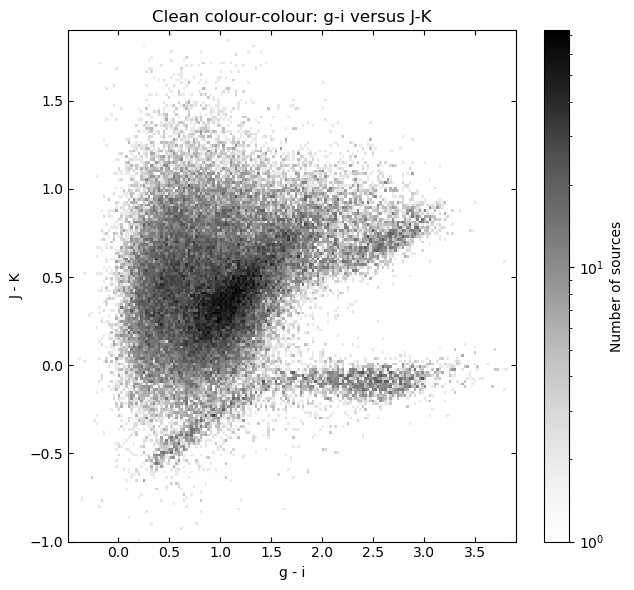

In [18]:
m_gi_JK = plot_colour_colour(
    x_bands=("g", "i"),
    y_bands=("J", "K"),
    xlim=(-0.49, 3.9),
    ylim=(-1.0, 1.9),
    title="Clean colour-colour: g-i versus J-K",
)


Clean colour-colour: u-i versus J-K
  bands used: ['J', 'K', 'i', 'u']
  N selected: 22963


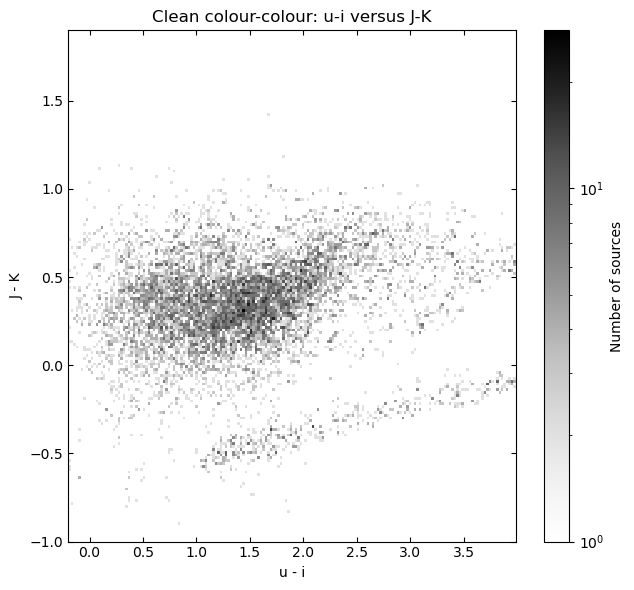

In [19]:
try:
    m_ui_JK = plot_colour_colour(
        x_bands=("u", "i"),
        y_bands=("J", "K"),
        xlim=(-0.2, 3.99),
        ylim=(-1.0, 1.9),
        title="Clean colour-colour: u-i versus J-K",
    )
except KeyError as e:
    print("Skipping u-i versus J-K because a required column is missing:")
    print(e)


Clean colour-colour: r-i versus J-K
  bands used: ['J', 'K', 'i', 'r']
  N selected: 113402


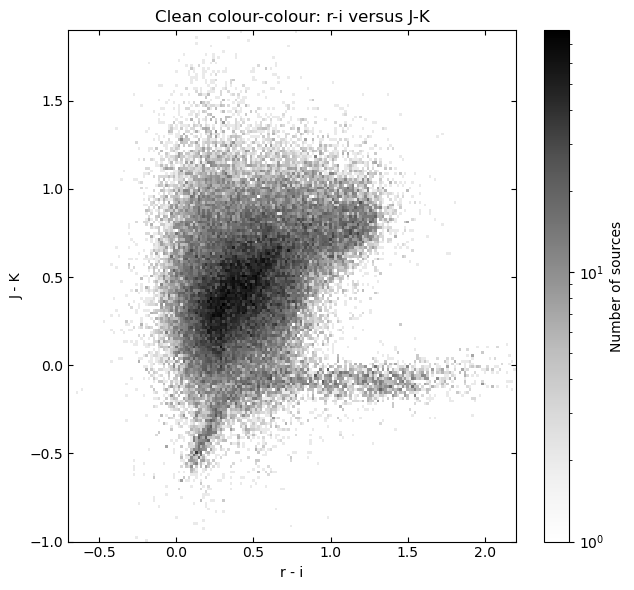

In [20]:
try:
    m_ri_JK = plot_colour_colour(
        x_bands=("r", "i"),
        y_bands=("J", "K"),
        xlim=(-0.7, 2.2),
        ylim=(-1.0, 1.9),
        title="Clean colour-colour: r-i versus J-K",
    )
except KeyError as e:
    print("Skipping r-i versus J-K because a required column is missing:")
    print(e)


Clean optical colour-colour: g-r versus r-i
  bands used: ['g', 'i', 'r']
  N selected: 142011


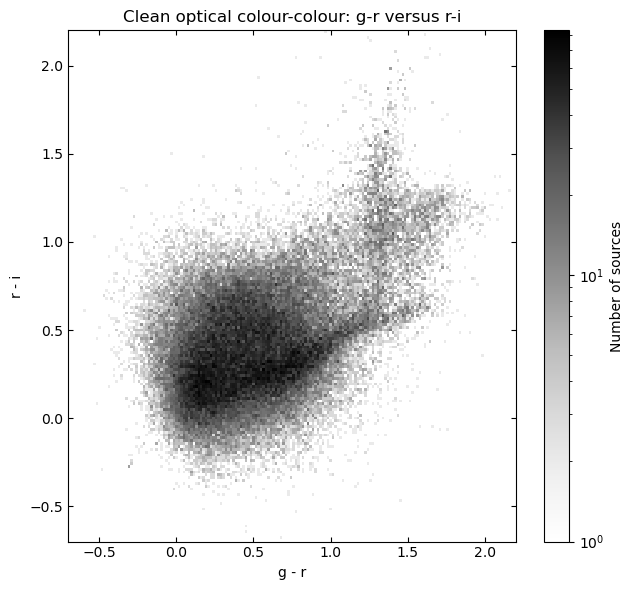

In [21]:
try:
    m_gr_ri = plot_colour_colour(
        x_bands=("g", "r"),
        y_bands=("r", "i"),
        xlim=(-0.7, 2.2),
        ylim=(-0.7, 2.2),
        title="Clean optical colour-colour: g-r versus r-i",
    )
except KeyError as e:
    print("Skipping g-r versus r-i because a required column is missing:")
    print(e)


Clean NIR colour-colour: Y-J versus J-K
  bands used: ['J', 'K', 'Y']
  N selected: 428982


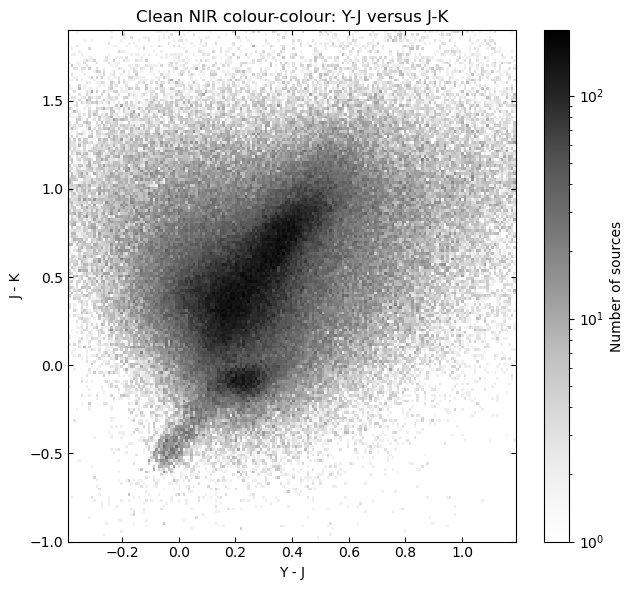

In [22]:
try:
    m_YJ_JK = plot_colour_colour(
        x_bands=("Y", "J"),
        y_bands=("J", "K"),
        xlim=(-0.39, 1.19),
        ylim=(-1.0, 1.9),
        title="Clean NIR colour-colour: Y-J versus J-K",
    )
except KeyError as e:
    print("Skipping Y-J versus J-K because a required column is missing:")
    print(e)

### 10. Baldry-like diagnostic using clean per-band cuts

This stellar-locus-style diagnostic uses forced photometry in g, i, J, and K with the same per-band quality selection adopted above: an unset aperture measurement flag, no selected severe PixelFlags, and forced-flux S/N >= 5. Primary-source and extendedness information is taken from the common object catalogue.

The empirical stellar locus is fitted only as a diagnostic from point-like sources and is not used to modify the measured colours.

N selected: 35696
extendedness column: ComCam_i_m_base_ClassificationExtendedness_value
primary column: VIRCAM_K_m_detect_isPrimary


/tmp/ipykernel_40339/1987311527.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


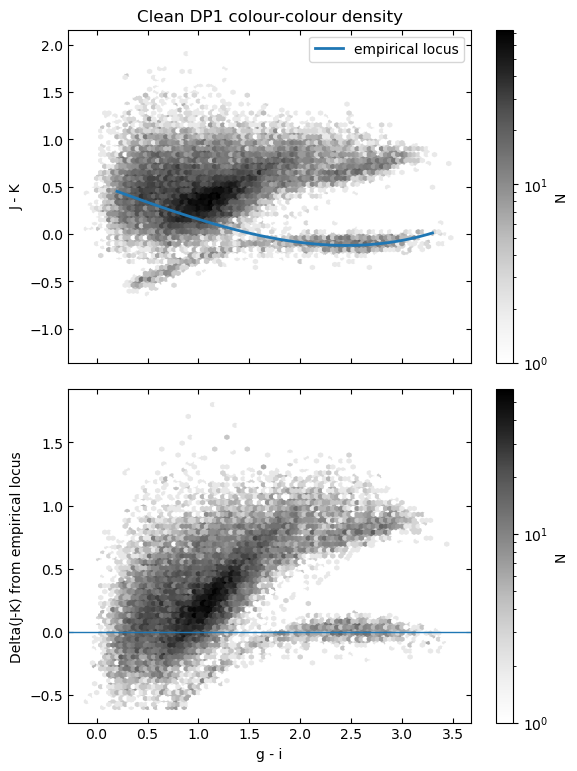

In [23]:
def get_optional_column(tab, candidates, dtype=float):
    for col in candidates:
        if has_col(tab, col):
            return np.asarray(tab[col], dtype=dtype), col
    return None, None


ext, ext_col = get_optional_column(
    dp1c,
    [
        "ComCam_i_m_base_ClassificationExtendedness_value",
        "ComCam_i_m_base_ClassificationExtendedness_value",
        "VIRCAM_K_m_base_ClassificationExtendedness_value",
    ],
    dtype=float,
)

primary, primary_col = get_optional_column(
    dp1c,
    [
        "VIRCAM_K_m_detect_isPrimary",
        "ComCam_i_m_detect_isPrimary",
    ],
    dtype=bool,
)

mask = (
    dp1_band_usable(dp1c, "g", snr_min=5.0)
    & dp1_band_usable(dp1c, "i", snr_min=5.0)
    & dp1_band_usable(dp1c, "J", snr_min=5.0)
    & dp1_band_usable(dp1c, "K", snr_min=5.0)
)

if primary is not None:
    mask &= primary

if ext is not None:
    mask &= np.isfinite(ext)

mask &= dp1_mag(dp1c, "K") < 23.5

gi = dp1_colour(dp1c, "g", "i")
JK = dp1_colour(dp1c, "J", "K")

mask &= (
    np.isfinite(gi)
    & np.isfinite(JK)
    & (gi > -1.0)
    & (gi < 3.5)
    & (JK > -1.0)
    & (JK < 2.0)
)

print("N selected:", int(mask.sum()))
print("extendedness column:", ext_col)
print("primary column:", primary_col)

gi_m = gi[mask]
JK_m = JK[mask]

if ext is not None:
    ext_m = ext[mask]
    star_like = ext_m < 0.5
else:
    # If no morphology column is available, use all sources to define a rough locus.
    star_like = np.ones(len(gi_m), dtype=bool)

bins = np.arange(0.2, 3.31, 0.10)
xc = 0.5 * (bins[:-1] + bins[1:])
med = np.full(len(xc), np.nan)
npt = np.zeros(len(xc), dtype=int)

for ii in range(len(xc)):
    mbin = star_like & (gi_m >= bins[ii]) & (gi_m < bins[ii + 1])
    npt[ii] = int(mbin.sum())
    if npt[ii] >= 30:
        med[ii] = np.nanmedian(JK_m[mbin])

ok = np.isfinite(med)
if ok.sum() >= 4:
    coef = np.polyfit(xc[ok], med[ok], deg=3)
    poly = np.poly1d(coef)
    delta = JK_m - poly(gi_m)
else:
    poly = None
    delta = np.full(len(gi_m), np.nan)

fig, axes = plt.subplots(
    2, 1,
    figsize=(6.5, 9),
    sharex=True,
    gridspec_kw={"hspace": 0.08},
)

hb0 = axes[0].hexbin(
    gi_m,
    JK_m,
    gridsize=90,
    extent=(-0.1, 3.5, -1.2, 2.0),
    mincnt=1,
    cmap="Greys",
    norm=LogNorm(),
)
axes[0].set_ylabel("J - K")
axes[0].set_title("Clean DP1 colour-colour density")
axes[0].tick_params(direction="in", top=True, right=True)
fig.colorbar(hb0, ax=axes[0], label="N")

if poly is not None:
    xline = np.linspace(0.2, 3.3, 300)
    axes[0].plot(xline, poly(xline), lw=2, label="empirical locus")
    axes[0].legend(loc="best")

hb1 = axes[1].hexbin(
    gi_m,
    delta,
    gridsize=90,
    extent=(-0.1, 3.5, -0.6, 1.8),
    mincnt=1,
    cmap="Greys",
    norm=LogNorm(),
)
axes[1].axhline(0, lw=1)
axes[1].set_xlabel("g - i")
axes[1].set_ylabel("Delta(J-K) from empirical locus")
axes[1].tick_params(direction="in", top=True, right=True)
fig.colorbar(hb1, ax=axes[1], label="N")

plt.tight_layout()
savefig("dp1_clean_baldry_like_colour_diagnostic.png")
plt.show()

### 11. Publication figure: optical--near-infrared colour distribution

The publication colour distribution uses forced photometry consistently in g, i, J, and K. Each band is required to pass the aperture and selected pixel-quality flags and to have forced-flux S/N >= 5. The sample is additionally restricted to primary catalogue sources.

The figure is used as a diagnostic of the coherence of the combined optical--near-infrared catalogue rather than to define a source-classification boundary.

Optical--near-infrared colour distribution
Primary column    : VIRCAM_K_m_detect_isPrimary
Forced S/N limit  : 5
Clean sources     : 50,698


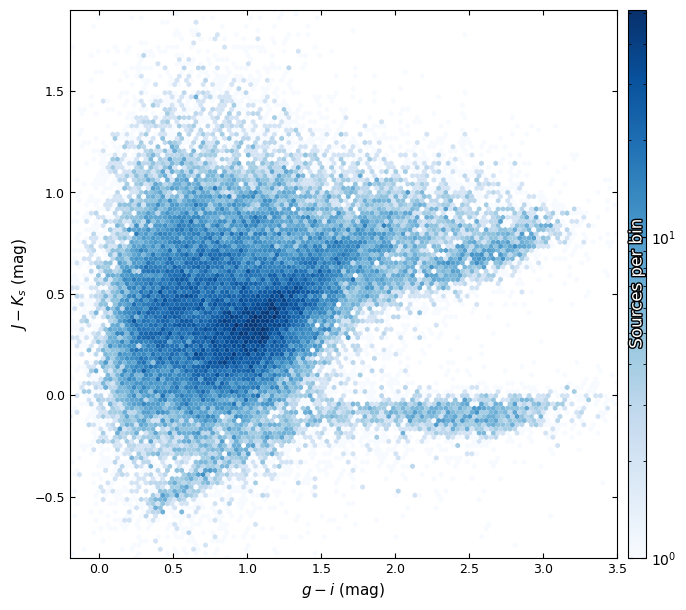


Saved figure to:
data/plots_photometry/dp1_gi_JKs_colour_distribution.pdf


In [24]:
from matplotlib.colors import LogNorm
import matplotlib.patheffects as pe


# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

SNR_MIN = 5.0

X_LIMITS = (-0.2, 3.5)
Y_LIMITS = (-0.8, 1.9)

HEXBIN_GRIDSIZE = 115

OUTPUT_PATH = (
    OUTDIR / "dp1_gi_JKs_colour_distribution.pdf"
)


# ------------------------------------------------------------------
# Optical--near-infrared colours
# ------------------------------------------------------------------

gi = dp1_colour(
    dp1c,
    "g",
    "i",
)

JKs = dp1_colour(
    dp1c,
    "J",
    "K",
)


# ------------------------------------------------------------------
# Clean primary-source sample
# ------------------------------------------------------------------

primary_col = "VIRCAM_K_m_detect_isPrimary"

primary = np.asarray(
    dp1c[primary_col],
    dtype=bool,
)

mask = primary.copy()

for band in ["g", "i", "J", "K"]:
    mask &= dp1_band_usable(
        dp1c,
        band,
        snr_min=SNR_MIN,
    )

mask &= (
    np.isfinite(gi)
    & np.isfinite(JKs)
    & (gi > X_LIMITS[0])
    & (gi < X_LIMITS[1])
    & (JKs > Y_LIMITS[0])
    & (JKs < Y_LIMITS[1])
)


# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.2, 6.6),
)

fig.subplots_adjust(
    left=0.12,
    right=0.88,
    bottom=0.14,
    top=0.97,
)

density = ax.hexbin(
    gi[mask],
    JKs[mask],
    gridsize=HEXBIN_GRIDSIZE,
    extent=(
        X_LIMITS[0],
        X_LIMITS[1],
        Y_LIMITS[0],
        Y_LIMITS[1],
    ),
    mincnt=1,
    cmap="Blues",
    norm=LogNorm(vmin=1),
    linewidths=0,
    rasterized=True,
)

ax.set_xlim(*X_LIMITS)
ax.set_ylim(*Y_LIMITS)

ax.set_xlabel(
    r"$g-i$ (mag)",
    fontsize=11,
)

ax.set_ylabel(
    r"$J-K_s$ (mag)",
    fontsize=11,
)

ax.tick_params(
    axis="both",
    direction="in",
    top=True,
    right=True,
    labelsize=9,
)


# ------------------------------------------------------------------
# Colour bar
# ------------------------------------------------------------------

colourbar_axis = fig.add_axes(
    [0.895, 0.14, 0.025, 0.83]
)

colourbar = fig.colorbar(
    density,
    cax=colourbar_axis,
)

colourbar.ax.tick_params(
    which="both",
    direction="in",
    right=True,
    left=True,
)

colourbar.ax.text(
    0.5,
    0.5,
    "Sources per bin",
    transform=colourbar.ax.transAxes,
    rotation=90,
    ha="center",
    va="center",
    color="white",
    fontsize=12,
    path_effects=[
        pe.withStroke(
            linewidth=2,
            foreground="black",
        )
    ],
)


# ------------------------------------------------------------------
# Report and save
# ------------------------------------------------------------------

print(
    "Optical--near-infrared colour distribution"
)

print(
    f"Primary column    : {primary_col}"
)

print(
    f"Forced S/N limit  : {SNR_MIN:.0f}"
)

print(
    f"Clean sources     : {mask.sum():,}"
)

fig.savefig(
    OUTPUT_PATH,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.show()

print(
    f"\nSaved figure to:\n{OUTPUT_PATH}"
)